# Input/Output Visualization - PyPSA Isolated
This notebook contains only charts and tables.
The model and optimization are executed from `config.py`.

In [9]:
import warnings
warnings.filterwarnings('ignore')

import importlib
import matplotlib.pyplot as plt
import build_demand
import config

# Reload both modules in case they changed during the session
build_demand = importlib.reload(build_demand)
config = importlib.reload(config)

config.configure_runtime_output()
plt.style.use('seaborn-v0_8-whitegrid')

# Consistent color palette by technology (use across all technology cells)
TECH_COLORS = {
    'wind': '#5bbcff',      # light blue
    'solar': '#ffd54f',     # yellow
    'ocgt': '#b85c5c',      # muted red
    'bess': '#9966cc',      # purple (battery)
    'electrolyzer': '#00897b',
    'h2_fuel_cell': '#ff8f00',
    'h2_turbine': '#6d4c41',
    'hydrogen_storage': '#26a69a',
    'uhs_injection': '#1e88e5',
    'uhs_withdrawal': '#3949ab',
    'uhs_storage': '#8e24aa',
    'slack': '#d32f2f',     # red (unserved energy)
    'natural_gas': '#bdbdbd',  # light gray
    'gas': '#bdbdbd',       # light gray (alias)
}

In [10]:
# Run optimization for multiple years using the generic API
years = [2025, 2030, 2040, 2050]
detailed_year = years[-1]
case_folder = "input_new_zealand"
case_name = "new_zealand"
weather_year = 2025  # Weather data year (cutout auto-saved as data/{case_name}_{weather_year}.nc)
paths = config.get_case_paths(case_folder)

# Enable or disable the entire hydrogen chain
enable_hydrogen = True

# Enable or disable heat sector (heat pumps, gas boilers, heat demand)
enable_heat = False

# Explicit technology assumptions for VRE profiles with atlite
vre_profile_method = "atlite_technology"
wind_turbine = "Vestas_V112_3MW"
solar_panel = "CSi"
solar_orientation = "latitude_optimal"

# Deep decarbonization example: year 2050 with strict CO2 cap
co2_cap_by_year = {2050: 0}

all_results = config.run_case_multiple_years(
    years=years,
    weather_year=weather_year,
    case_name=case_name,
    solver_name='gurobi',
    time_limit=2000,      # seconds per year
    mip_gap=0.02,        # 2% relative gap
    threads=8,           # adjust to your CPU
    prepare_cutout=False,
    fallback_to_highs=True,
    enable_year_linking=True,
    enable_hydrogen=enable_hydrogen,
    enable_heat=enable_heat,
    co2_cap_tons=co2_cap_by_year,
    vre_profile_method=vre_profile_method,
    wind_turbine=wind_turbine,
    solar_panel=solar_panel,
    solar_orientation=solar_orientation,
    **paths,
 )

# Use the selected year for detailed analysis
n = all_results[detailed_year]['network']
load = all_results[detailed_year]['load']
heat_load = all_results[detailed_year].get('heat_load')
wind_cf = all_results[detailed_year]['wind_cf']
solar_cf = all_results[detailed_year]['solar_cf']

print(f"\n{'='*60}")
print("RESULTS SUMMARY")
print(f"{'='*60}")
print(f"Case: {case_name} | Cutout: {all_results[detailed_year].get('cutout_path', 'N/A')}")
print(f"VRE method: {vre_profile_method} | Turbine: {wind_turbine} | Panel: {solar_panel}")
print(f"Hydrogen enabled: {enable_hydrogen}")
print(f"Heat enabled: {heat_load is not None and not heat_load.empty}")
print(f"CO2 cap by year: {co2_cap_by_year}")
print(f"Detailed year for the following charts: {detailed_year}")
for year in years:
    result = all_results[year]
    print(f"\n{year}:")
    print(f"  Solver: {result['solver']}")
    print(f"  Status: {result['status']} | Condition: {result['condition']}")
    print(f"  Objective: €{result['objective']:,.2f}")


Running optimization for new_zealand - 2025...
Synthetic fallback demand used while running case 'new_zealand' (CSV: input_new_zealand/demand_profiles.csv). Demand types: electricity. Zones: auckland, christchurch, dunedin, hamilton, wellington


INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.


Gurobi failed: Solver gurobi not installed. Using HiGHS.


Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 67.60it/s]


Objective (2025): 1,079,680,383.42
Solver: highs

Running optimization for new_zealand - 2030...
  (with year-linking from 2025)
Synthetic fallback demand used while running case 'new_zealand' (CSV: input_new_zealand/demand_profiles.csv). Demand types: electricity. Zones: auckland, christchurch, dunedin, hamilton, wellington


...

Objective (2040): 1,079,537,783.73
Solver: highs

Running optimization for new_zealand - 2050...
  (with year-linking from 2040)
Synthetic fallback demand used while running case 'new_zealand' (CSV: input_new_zealand/demand_profiles.csv). Demand types: electricity. Zones: auckland, christchurch, dunedin, hamilton, wellington


INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.


Gurobi failed: Solver gurobi not installed. Using HiGHS.


Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00, 93.45it/s]


Objective (2050): 2,547,721,960.46
Solver: highs

RESULTS SUMMARY
Case: new_zealand | Cutout: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\4_PyPSA-Isolated\model\data\new_zealand_2025.nc
VRE method: atlite_technology | Turbine: Vestas_V112_3MW | Panel: CSi
Hydrogen enabled: True
Heat enabled: False
CO2 cap by year: {2050: 0}
Detailed year for the following charts: 2050

2025:
  Solver: highs
  Status: ok | Condition: optimal
  Objective: €1,079,680,383.42

2030:
  Solver: highs
  Status: ok | Condition: optimal
  Objective: €1,078,676,050.01

2040:
  Solver: highs
  Status: ok | Condition: optimal
  Objective: €1,079,537,783.73

2050:
  Solver: highs
  Status: ok | Condition: optimal
  Objective: €2,547,721,960.46


In [11]:
# ── Export multi-year results to CSV ─────────────────────────────────────────
# Creates output_YYYY_MM_DD/ (or output_YYYY_MM_DD_2/, _3/, …) in the case folder
output_dir = config.export_results_to_csv(
    all_results,
    case_name=case_name,
    output_base_dir=case_folder,
)
print(f"\nResults exported to: {output_dir}")

Exporting results to: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\4_PyPSA-Isolated\model\output_new_zealand_2026_05_26_2
  ✓ new_zealand_solver_summary.csv
  ✓ new_zealand_capacity_by_year.csv
  ✓ new_zealand_links_by_year.csv
  ✓ new_zealand_stores_by_year.csv
  ✓ new_zealand_dispatch_by_year.csv
  ✓ new_zealand_demand_by_year.csv
  ✓ link_flows/new_zealand_link_flows_<year>.csv  (per year)
  ✓ new_zealand_co2_by_year.csv

Results exported to: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\4_PyPSA-Isolated\model\output_new_zealand_2026_05_26_2


In [12]:
# Heat sector analysis: demand, dispatch, and capacities
import pandas as pd

def _heat_series_for_year(results_dict, year):
    """Extract heat demand and supply time series for a given year."""
    net = results_dict[year]['network']
    heat_df = results_dict[year].get('heat_load', pd.DataFrame())
    if heat_df is None or heat_df.empty:
        return None

    total_heat = heat_df.sum(axis=1)
    gas_links = net.links.index[net.links['carrier'] == 'gas_boiler'] if len(net.links) > 0 else []
    hp_links = net.links.index[net.links['carrier'] == 'heat_pump'] if len(net.links) > 0 else []

    gas_heat = pd.Series(0.0, index=net.snapshots)
    hp_heat = pd.Series(0.0, index=net.snapshots)
    hp_power = pd.Series(0.0, index=net.snapshots)

    if len(gas_links) > 0:
        gas_heat = net.links_t.p1[gas_links].abs().sum(axis=1)

    if len(hp_links) > 0:
        hp_heat = net.links_t.p1[hp_links].abs().sum(axis=1)
        hp_power = net.links_t.p0[hp_links].abs().sum(axis=1)

    return {
        'network': net,
        'heat_load': heat_df,
        'total_heat_load': total_heat,
        'gas_boiler_heat': gas_heat,
        'heat_pump_heat': hp_heat,
        'heat_pump_power': hp_power,
    }

def _plot_heat_supply_area(ax, total_heat, gas_heat, hp_heat, title, resample_rule='D'):
    """Plot stacked area of heat supply by technology, smoothed to daily averages."""
    supply = pd.concat(
        [gas_heat.rename('Gas boiler'), hp_heat.rename('Heat pump')],
        axis=1,
    ).fillna(0.0).clip(lower=0.0)

    total_for_plot = total_heat.copy()
    if resample_rule and len(supply) > 0:
        supply = supply.resample(resample_rule).mean()
        total_for_plot = total_for_plot.resample(resample_rule).mean()

    if supply.sum().sum() <= 0:
        total_for_plot.plot(
            ax=ax, color='#222222', linewidth=1.4, linestyle='--',
            label='Heat demand', zorder=3
        )
    else:
        supply.plot.area(
            ax=ax,
            stacked=True,
            color=['#8d6e63', '#42a5f5'],
            alpha=0.92,
            linewidth=0,
        )
        total_for_plot.plot(
            ax=ax, color='#222222', linewidth=1.3, linestyle='--',
            label='Heat demand', zorder=4
        )

    ax.set_title(title, fontsize=12, pad=12)
    ax.set_ylabel('MWth', fontsize=11)
    ax.set_xlabel('Time', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.25)

analysis_year = detailed_year
heat_data = _heat_series_for_year(all_results, analysis_year)

if heat_data is None:
    print(f"No heat demand configured for {analysis_year}.")
else:
    # Plot previous year if available (for comparison)
    previous_year = None
    if len(years) > 1:
        previous_candidates = [y for y in years if y < analysis_year]
        if previous_candidates:
            previous_year = max(previous_candidates)

    if previous_year is not None:
        prev_data = _heat_series_for_year(all_results, previous_year)
        if prev_data is not None:
            fig_prev, ax_prev = plt.subplots(1, 1, figsize=(14, 4.5))
            prev_total = prev_data['total_heat_load']
            prev_gas = prev_data['gas_boiler_heat']
            prev_hp = prev_data['heat_pump_heat']

            _plot_heat_supply_area(
                ax_prev, prev_total, prev_gas, prev_hp,
                f'Heat supply by technology (daily average) - {previous_year}'
            )
            plt.tight_layout()
            plt.show()

            print(f"\n=== HEAT SUMMARY {previous_year} ===")
            print(f"Annual heat demand: {prev_total.sum():,.0f} MWhth")
            print(f"Gas boiler heat: {prev_gas.sum():,.0f} MWhth")
            print(f"Heat pump heat: {prev_hp.sum():,.0f} MWhth")

    total_heat_load = heat_data['total_heat_load']
    gas_boiler_heat = heat_data['gas_boiler_heat']
    heat_pump_heat = heat_data['heat_pump_heat']
    heat_pump_power = heat_data['heat_pump_power']
    analysis_net = heat_data['network']

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

    # Panel 1: Total heat demand time series
    total_heat_load.plot(ax=axes[0], color='#111111', linewidth=1.8, label='Total heat demand')
    axes[0].set_title(f'Heat demand - {analysis_year}', fontsize=12, pad=15)
    axes[0].set_ylabel('MWth', fontsize=11)
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.25)

    # Panel 2: Heat supply by technology (stacked area, daily average)
    _plot_heat_supply_area(
        axes[1], total_heat_load, gas_boiler_heat, heat_pump_heat,
        f'Heat supply by technology (daily average) - {analysis_year}'
    )

    # Panel 3: Heat pump electricity consumption
    hp_power_daily = heat_pump_power.resample('D').mean() if len(heat_pump_power) > 0 else heat_pump_power
    hp_power_monthly = heat_pump_power.resample('ME').mean() if len(heat_pump_power) > 0 else heat_pump_power
    hp_power_avg = float(heat_pump_power.mean()) if len(heat_pump_power) > 0 else 0.0

    axes[2].plot(
        hp_power_daily.index, hp_power_daily,
        color='#64b5f6', linewidth=1.2, alpha=0.90,
        label='HP electricity consumption (daily avg)'
    )
    axes[2].plot(
        hp_power_monthly.index, hp_power_monthly,
        color='#0d47a1', linewidth=2.8, marker='o', markersize=5,
        label='HP electricity consumption (monthly avg)'
    )
    axes[2].axhline(
        hp_power_avg, color='#1b5e20', linewidth=1.8, linestyle='--',
        label=f'Annual average = {hp_power_avg:.2f} MWel'
    )
    axes[2].set_title(f'Heat pump electricity consumption - {analysis_year}', fontsize=12, pad=15)
    axes[2].set_ylabel('MWel', fontsize=11)
    axes[2].set_xlabel('Time', fontsize=11)
    axes[2].legend(loc='best', fontsize=8)
    axes[2].grid(True, alpha=0.25)

    max_hp = float(max(hp_power_daily.max(), hp_power_monthly.max())) if len(hp_power_daily) > 0 else 0.0
    axes[2].set_ylim(0, max(1.0, max_hp * 1.25))

    plt.tight_layout()
    plt.show()

    # Extra zoom figure (without sharex) to avoid visual compression artifacts
    fig_zoom, ax_zoom = plt.subplots(1, 1, figsize=(14, 4.5))
    ax_zoom.plot(
        hp_power_daily.index, hp_power_daily,
        color='#1976d2', linewidth=1.8, label='HP daily average'
    )
    ax_zoom.scatter(
        hp_power_monthly.index, hp_power_monthly,
        color='#0d47a1', s=35, label='HP monthly average', zorder=3
    )
    ax_zoom.axhline(
        hp_power_avg, color='#1b5e20', linewidth=1.8, linestyle='--',
        label=f'Annual average = {hp_power_avg:.2f} MWel'
    )
    ax_zoom.set_title(f'ZOOM - HP electricity consumption - {analysis_year}', fontsize=12, pad=12)
    ax_zoom.set_ylabel('MWel', fontsize=11)
    ax_zoom.set_xlabel('Time', fontsize=11)
    ax_zoom.set_ylim(0, max(1.0, max_hp * 1.25))
    ax_zoom.legend(loc='best', fontsize=9)
    ax_zoom.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Display heat sector link capacities
    heat_links = analysis_net.links[analysis_net.links['carrier'].isin(['gas_boiler', 'heat_pump'])].copy()
    if not heat_links.empty:
        heat_cap_col = 'p_nom_opt' if 'p_nom_opt' in heat_links.columns else 'p_nom'
        heat_caps = heat_links[['carrier', 'bus0', 'bus1', 'efficiency']].copy()
        heat_caps['capacity_mw'] = heat_links[heat_cap_col]
        print(f"\n=== HEAT SECTOR CAPACITIES ({analysis_year}) ===")
        display(heat_caps.sort_values(['carrier', 'capacity_mw'], ascending=[True, False]))

    print(f"\n=== HEAT SECTOR STATISTICS ({analysis_year}) ===")
    print(f"Annual heat demand: {total_heat_load.sum():,.0f} MWhth")
    print(f"Heat served by gas boiler: {gas_boiler_heat.sum():,.0f} MWhth")
    print(f"Heat served by heat pumps: {heat_pump_heat.sum():,.0f} MWhth")
    print(f"Heat pump electricity consumption: {heat_pump_power.sum():,.0f} MWhel")
    if heat_pump_power.sum() > 0:
        print(f"Average operating COP: {heat_pump_heat.sum() / heat_pump_power.sum():.2f}")
        print(f"Average HP power (hourly): {heat_pump_power.mean():.2f} MWel | peak: {heat_pump_power.max():.2f} MWel")

No heat demand configured for 2050.


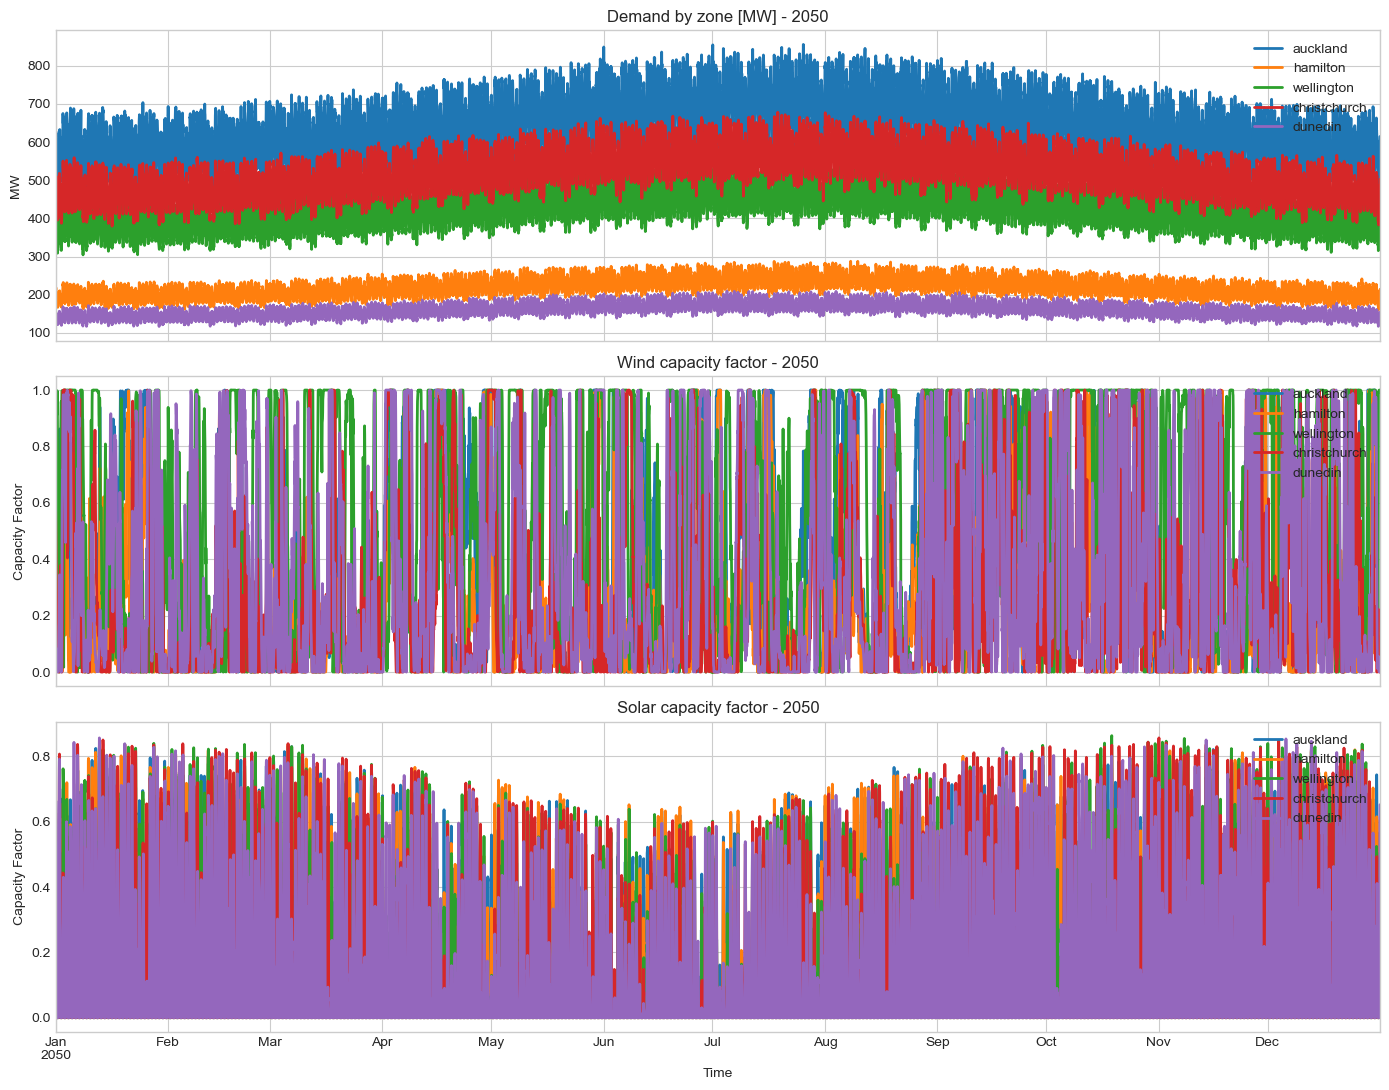

In [13]:
# Input profiles: demand, wind capacity factor, and solar capacity factor
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

load.plot(ax=axes[0], linewidth=2, title=f'Demand by zone [MW] - {detailed_year}', legend=True)
axes[0].set_ylabel('MW')
axes[0].get_legend().set_loc('upper right')

wind_cf.plot(ax=axes[1], linewidth=2, title=f'Wind capacity factor - {detailed_year}', legend=True)
axes[1].set_ylabel('Capacity Factor')
axes[1].get_legend().set_loc('upper right')

solar_cf.plot(ax=axes[2], linewidth=2, title=f'Solar capacity factor - {detailed_year}', legend=True)
axes[2].set_ylabel('Capacity Factor')
axes[2].set_xlabel('Time')
axes[2].get_legend().set_loc('upper right')

plt.tight_layout()
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


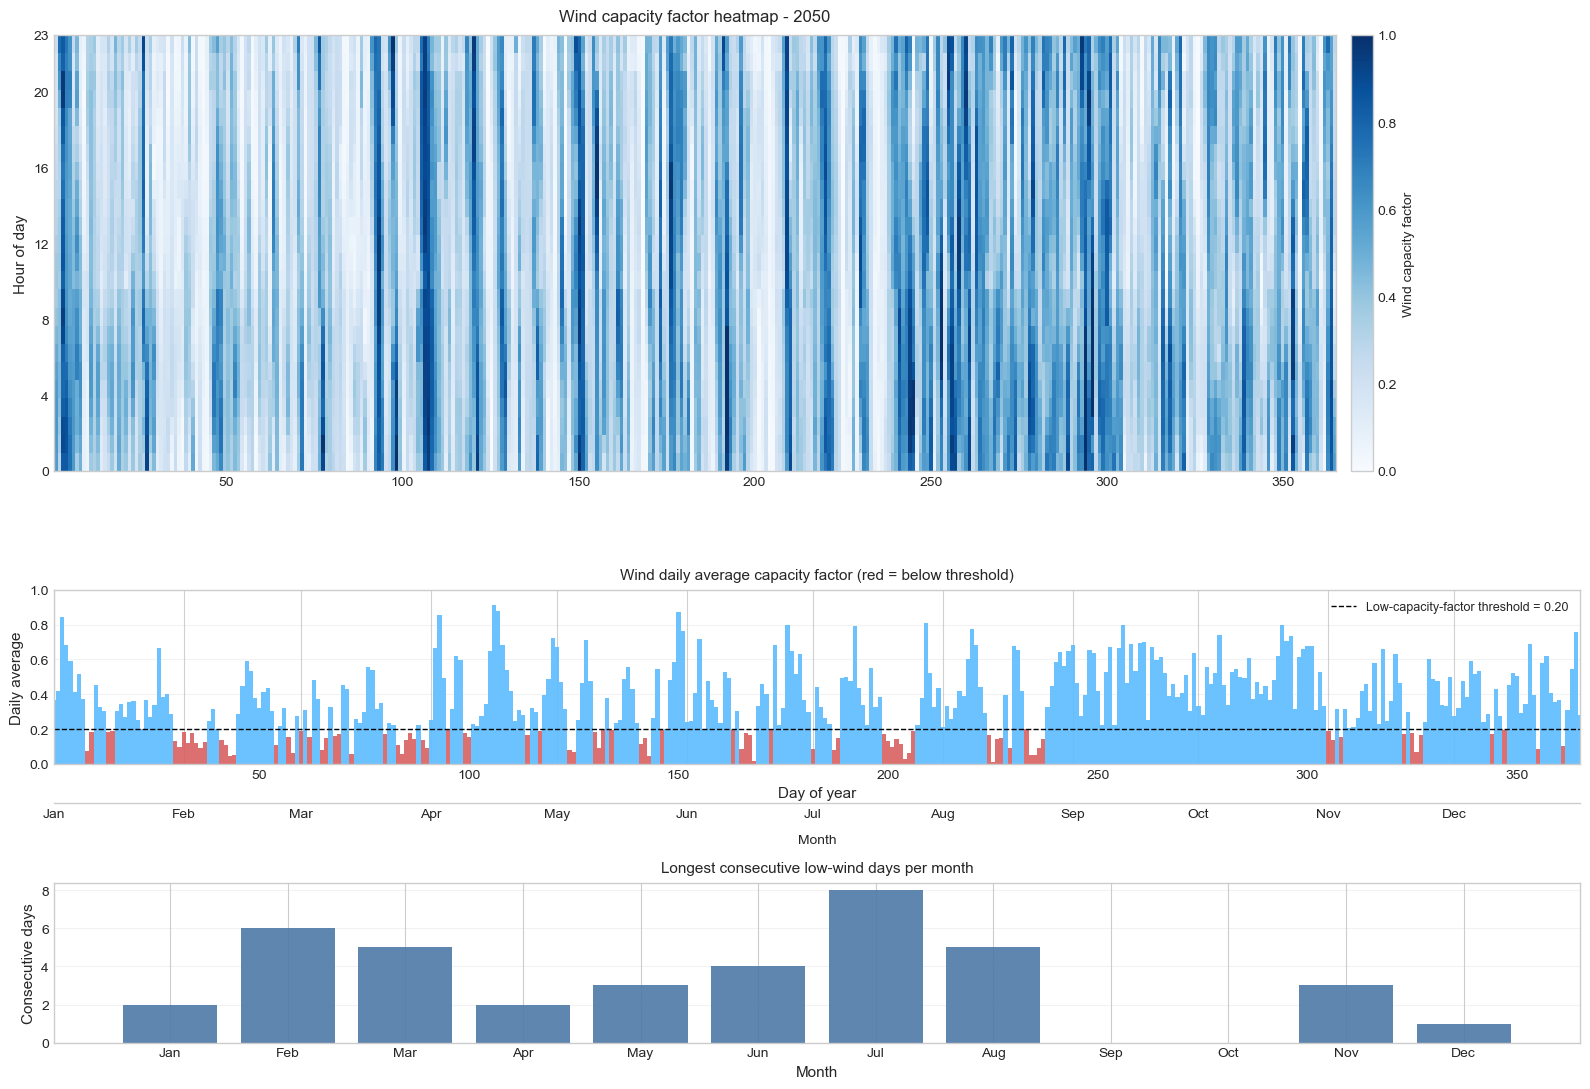

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


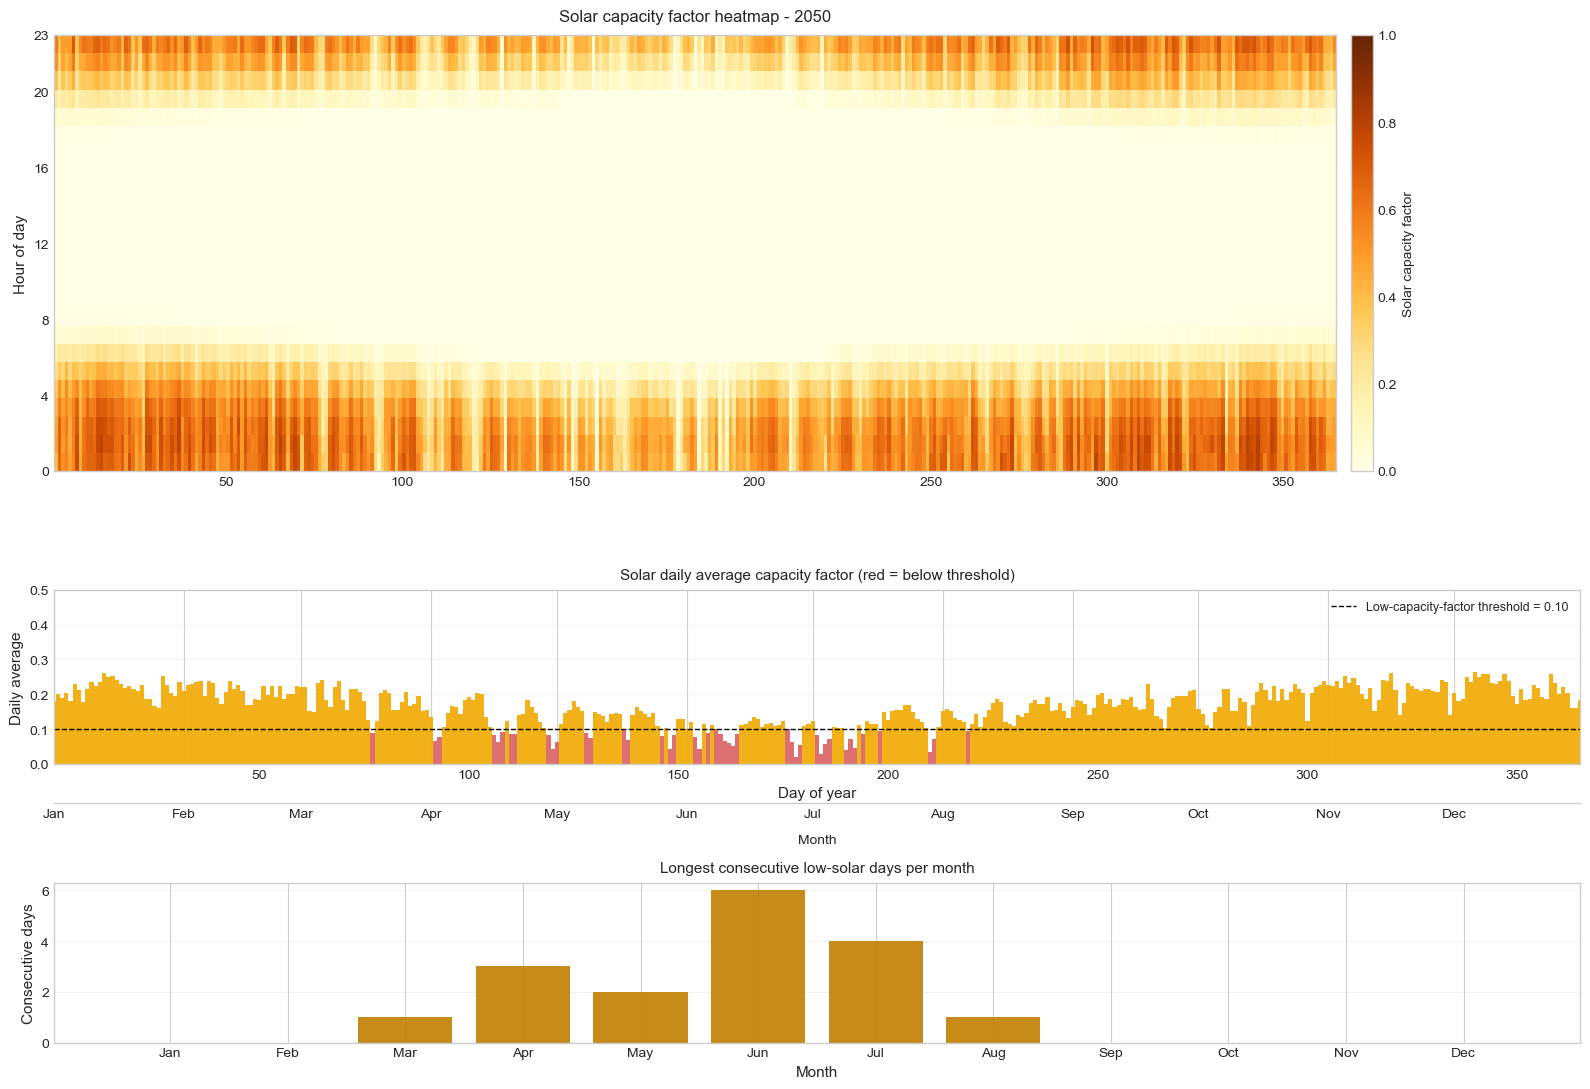

In [14]:
# Wind and solar capacity factor diagnostics (English labels)
import numpy as np
import pandas as pd

# Easy-to-tune thresholds for low-resource diagnostics
low_wind_threshold = 0.20
low_solar_threshold = 0.10

def _prepare_cf_series(cf_df: pd.DataFrame) -> pd.Series:
    if cf_df.empty:
        raise ValueError('No capacity factor data available to plot.')

    cf = cf_df.copy()
    if not isinstance(cf.index, pd.DatetimeIndex):
        cf.index = pd.to_datetime(cf.index)

    # Average across zones for each timestamp
    return cf.mean(axis=1)

def _cf_heatmap_matrix(cf_series: pd.Series) -> pd.DataFrame:
    data = pd.DataFrame({
        'capacity_factor': cf_series.values,
        'day': cf_series.index.dayofyear,
        'hour': cf_series.index.hour,
    })
    pivot = data.pivot_table(index='hour', columns='day', values='capacity_factor', aggfunc='mean')
    return pivot.reindex(index=range(24), columns=range(1, int(cf_series.index.dayofyear.max()) + 1))

def _daily_mean_series(cf_series: pd.Series) -> pd.Series:
    return cf_series.resample('D').mean()

def _monthly_max_consecutive_low_days(daily_cf: pd.Series, threshold: float) -> pd.Series:
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    result = pd.Series(0, index=month_labels, dtype=float)

    for month_num, month_data in daily_cf.groupby(daily_cf.index.month):
        mask = month_data.values < threshold
        max_len = 0
        cur_len = 0
        for is_low in mask:
            if is_low:
                cur_len += 1
                max_len = max(max_len, cur_len)
            else:
                cur_len = 0
        result.iloc[month_num - 1] = max_len

    return result

wind_series = _prepare_cf_series(wind_cf)
solar_series = _prepare_cf_series(solar_cf)
wind_matrix = _cf_heatmap_matrix(wind_series)
solar_matrix = _cf_heatmap_matrix(solar_series)
wind_daily = _daily_mean_series(wind_series)
solar_daily = _daily_mean_series(solar_series)
wind_streak_monthly = _monthly_max_consecutive_low_days(wind_daily, low_wind_threshold)
solar_streak_monthly = _monthly_max_consecutive_low_days(solar_daily, low_solar_threshold)

# ---- WIND: heatmap + daily average + monthly consecutive low-wind days ----
fig, axes = plt.subplots(
    3, 1, figsize=(16, 11), sharex=False,
    gridspec_kw={'height_ratios': [3, 1.2, 1.1]}
)

im_w = axes[0].imshow(
    wind_matrix.values,
    origin='lower',
    aspect='auto',
    cmap='Blues',
    vmin=0,
    vmax=1,
    extent=[1, wind_matrix.shape[1], 0, 23],
)
axes[0].set_title(f'Wind capacity factor heatmap - {detailed_year}', fontsize=12, pad=10)
axes[0].set_ylabel('Hour of day', fontsize=11)
axes[0].set_yticks([0, 4, 8, 12, 16, 20, 23])
axes[0].grid(False)
cbar_w = plt.colorbar(im_w, ax=axes[0], pad=0.01)
cbar_w.set_label('Wind capacity factor', fontsize=10)

wind_daily_day = wind_daily.index.dayofyear
wind_colors = np.where(wind_daily.values < low_wind_threshold, '#d95f5f', '#5bbcff')
axes[1].bar(wind_daily_day, wind_daily.values, color=wind_colors, width=1.0, alpha=0.9)
axes[1].axhline(
    low_wind_threshold, color='black', linestyle='--', linewidth=1,
    label=f'Low-capacity-factor threshold = {low_wind_threshold:.2f}'
)
axes[1].set_title('Wind daily average capacity factor (red = below threshold)', fontsize=11, pad=8)
axes[1].set_ylabel('Daily average', fontsize=11)
axes[1].set_xlabel('Day of year', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].set_xlim(1, wind_matrix.shape[1])
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].xaxis.grid(False, which='both')
axes[1].legend(loc='upper right', fontsize=9)

# Keep day-of-year on the main bottom axis and add month labels on lower bottom axis
month_starts = wind_daily.resample('MS').first().index
month_start_days = month_starts.dayofyear.values
month_start_labels = month_starts.strftime('%b')

ax_month_bottom = axes[1].secondary_xaxis('bottom')
ax_month_bottom.set_xticks(month_start_days)
ax_month_bottom.set_xticklabels(month_start_labels)
ax_month_bottom.spines['bottom'].set_position(('outward', 28))
ax_month_bottom.set_xlabel('Month', fontsize=10, labelpad=10)
ax_month_bottom.grid(False)
ax_month_bottom.xaxis.grid(False, which='both')

# Draw month boundaries explicitly to avoid mixed automatic x-grid spacing
for day in month_start_days:
    axes[1].axvline(day, color='#bcbcbc', linewidth=0.8, alpha=0.7, zorder=0)

axes[2].bar(wind_streak_monthly.index, wind_streak_monthly.values, color='#4e79a7', alpha=0.9)
axes[2].set_title('Longest consecutive low-wind days per month', fontsize=11, pad=8)
axes[2].set_ylabel('Consecutive days', fontsize=11)
axes[2].set_xlabel('Month', fontsize=11)
axes[2].grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# ---- SOLAR: heatmap + daily average + monthly consecutive low-solar days ----
fig, axes = plt.subplots(
    3, 1, figsize=(16, 11), sharex=False,
    gridspec_kw={'height_ratios': [3, 1.2, 1.1]}
)

im_s = axes[0].imshow(
    solar_matrix.values,
    origin='lower',
    aspect='auto',
    cmap='YlOrBr',
    vmin=0,
    vmax=1,
    extent=[1, solar_matrix.shape[1], 0, 23],
)
axes[0].set_title(f'Solar capacity factor heatmap - {detailed_year}', fontsize=12, pad=10)
axes[0].set_ylabel('Hour of day', fontsize=11)
axes[0].set_yticks([0, 4, 8, 12, 16, 20, 23])
axes[0].grid(False)
cbar_s = plt.colorbar(im_s, ax=axes[0], pad=0.01)
cbar_s.set_label('Solar capacity factor', fontsize=10)

solar_daily_day = solar_daily.index.dayofyear
solar_colors = np.where(solar_daily.values < low_solar_threshold, '#d95f5f', '#f2a900')
axes[1].bar(solar_daily_day, solar_daily.values, color=solar_colors, width=1.0, alpha=0.9)
axes[1].axhline(
    low_solar_threshold, color='black', linestyle='--', linewidth=1,
    label=f'Low-capacity-factor threshold = {low_solar_threshold:.2f}'
)
axes[1].set_title('Solar daily average capacity factor (red = below threshold)', fontsize=11, pad=8)
axes[1].set_ylabel('Daily average', fontsize=11)
axes[1].set_xlabel('Day of year', fontsize=11)
axes[1].set_ylim(0, 0.5)
axes[1].set_xlim(1, solar_matrix.shape[1])
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].xaxis.grid(False, which='both')
axes[1].legend(loc='upper right', fontsize=9)

# Match month labels and month boundary lines as in wind daily chart
solar_month_starts = solar_daily.resample('MS').first().index
solar_month_start_days = solar_month_starts.dayofyear.values
solar_month_start_labels = solar_month_starts.strftime('%b')

ax_solar_month_bottom = axes[1].secondary_xaxis('bottom')
ax_solar_month_bottom.set_xticks(solar_month_start_days)
ax_solar_month_bottom.set_xticklabels(solar_month_start_labels)
ax_solar_month_bottom.spines['bottom'].set_position(('outward', 28))
ax_solar_month_bottom.set_xlabel('Month', fontsize=10, labelpad=10)
ax_solar_month_bottom.grid(False)
ax_solar_month_bottom.xaxis.grid(False, which='both')

for day in solar_month_start_days:
    axes[1].axvline(day, color='#bcbcbc', linewidth=0.8, alpha=0.7, zorder=0)

axes[2].bar(solar_streak_monthly.index, solar_streak_monthly.values, color='#c17f00', alpha=0.9)
axes[2].set_title('Longest consecutive low-solar days per month', fontsize=11, pad=8)
axes[2].set_ylabel('Consecutive days', fontsize=11)
axes[2].set_xlabel('Month', fontsize=11)
axes[2].grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [15]:
# Optimized generator and link capacities overview
gen_caps = n.generators[['bus', 'carrier', 'p_nom_opt']].sort_values('p_nom_opt', ascending=False)
link_caps = n.links[['bus0', 'bus1', 'p_nom']]
display(gen_caps)
display(link_caps)

,bus,carrier,p_nom_opt
name,,,
slack_auckland,elec_auckland,slack,1000000.000000
slack_hamilton,elec_hamilton,slack,1000000.000000
slack_wellington,elec_wellington,slack,1000000.000000
slack_christchurch,elec_christchurch,slack,1000000.000000
slack_dunedin,elec_dunedin,slack,1000000.000000
wind_wellington,elec_wellington,wind,2981.099827
wind_christchurch,elec_christchurch,wind,2281.931709
wind_auckland,elec_auckland,wind,2028.188784
solar_auckland,elec_auckland,solar,1769.625245


,bus0,bus1,p_nom
name,,,
link_auckland_to_hamilton,elec_auckland,elec_hamilton,2000.0
link_hamilton_to_auckland,elec_hamilton,elec_auckland,2000.0
link_hamilton_to_wellington,elec_hamilton,elec_wellington,1500.0
link_wellington_to_hamilton,elec_wellington,elec_hamilton,1500.0
link_wellington_to_christchurch,elec_wellington,elec_christchurch,1200.0
link_christchurch_to_wellington,elec_christchurch,elec_wellington,1200.0
link_christchurch_to_dunedin,elec_christchurch,elec_dunedin,1000.0
link_dunedin_to_christchurch,elec_dunedin,elec_christchurch,1000.0



=== INSTALLED CAPACITY BY TECHNOLOGY AND YEAR [MW] ===


carrier,wind,solar,ocgt
2025,3849.19,2105.62,1981.59
2030,3864.87,2108.07,1981.59
2040,3868.75,2146.43,1981.59
2050,8569.16,4200.60,1981.59


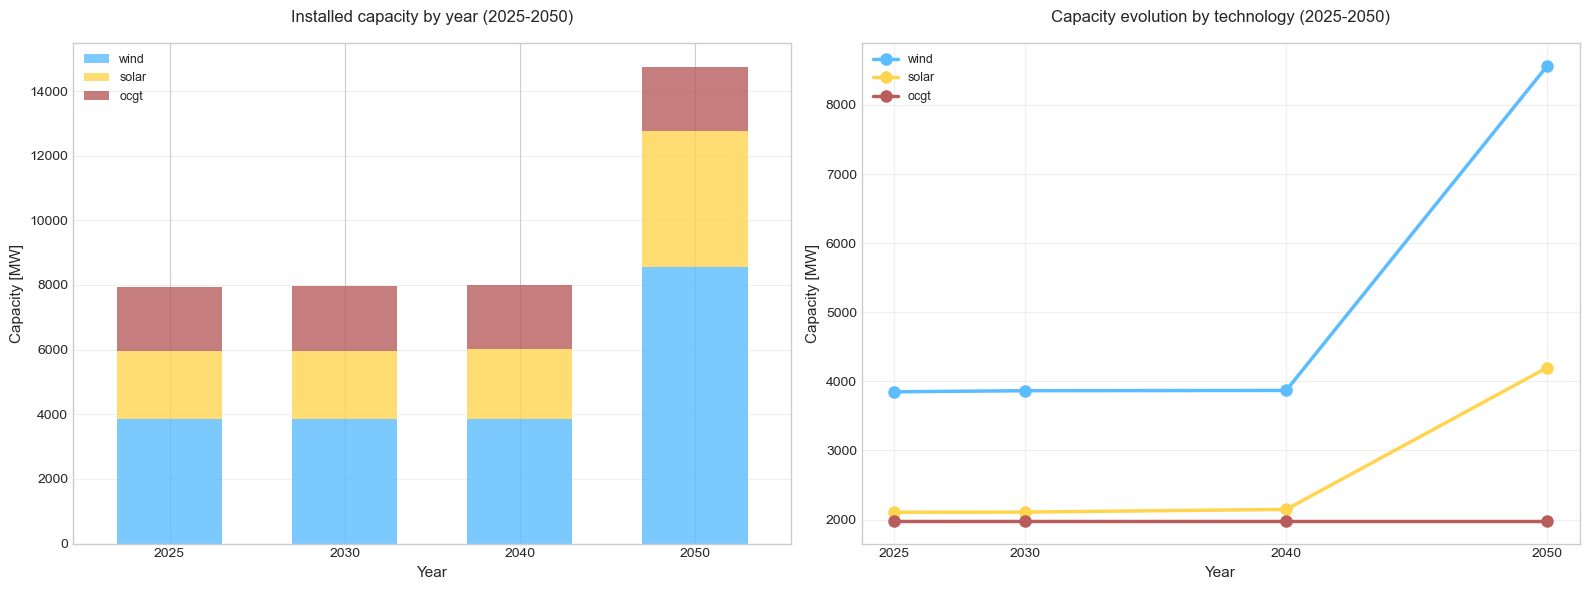


=== INSTALLED CAPACITY GROWTH ===

WIND:
  2025: 3849.2 MW
  2030: 3864.9 MW
  2040: 3868.7 MW
  2050: 8569.2 MW
  Growth 2025-2050: 4720.0 MW (122.6%)

SOLAR:
  2025: 2105.6 MW
  2030: 2108.1 MW
  2040: 2146.4 MW
  2050: 4200.6 MW
  Growth 2025-2050: 2095.0 MW (99.5%)

OCGT:
  2025: 1981.6 MW
  2030: 1981.6 MW
  2040: 1981.6 MW
  2050: 1981.6 MW
  Growth 2025-2050: 0.0 MW (0.0%)

=== TOTAL CAPACITY ===
2025: 7936.4 MW
2030: 7954.5 MW
2040: 7996.8 MW
2050: 14751.4 MW


In [16]:
# Installed capacity comparison across years
import pandas as pd
import numpy as np

period_start = years[0]
period_end = years[-1]

# Extract capacities by technology and year
capacity_by_year = {}
for year in years:
    net = all_results[year]['network']

    # Generators by technology
    gen_by_tech = net.generators.groupby('carrier')['p_nom_opt'].sum()

    # BESS (storage units)
    if len(net.storage_units) > 0:
        bess_cap = net.storage_units['p_nom_opt'].sum()
        gen_by_tech['bess'] = bess_cap

    capacity_by_year[year] = gen_by_tech

# Build DataFrame with all technologies and years
cap_df = pd.DataFrame(capacity_by_year).T.fillna(0)
cap_df = cap_df[['wind', 'solar', 'bess', 'ocgt']] if 'bess' in cap_df.columns else cap_df[['wind', 'solar', 'ocgt']]

# Color fallback
if 'TECH_COLORS' not in globals():
    TECH_COLORS = {
        'wind': '#5bbcff',
        'solar': '#ffd54f',
        'ocgt': '#b85c5c',
        'bess': '#9966cc',
        'slack': '#d32f2f',
        'natural_gas': '#bdbdbd',
        'gas': '#bdbdbd',
    }

print("\n=== INSTALLED CAPACITY BY TECHNOLOGY AND YEAR [MW] ===")
display(cap_df.round(2))

# Comparative plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Stacked bars by year
tech_colors = [TECH_COLORS.get(t, '#999999') for t in cap_df.columns]
cap_df.plot.bar(ax=axes[0], stacked=True, color=tech_colors, alpha=0.8, width=0.6)
axes[0].set_title(f'Installed capacity by year ({period_start}-{period_end})', fontsize=12, pad=15)
axes[0].set_ylabel('Capacity [MW]', fontsize=11)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Plot 2: Technology evolution lines
for tech in cap_df.columns:
    axes[1].plot(cap_df.index, cap_df[tech], marker='o', linewidth=2.5,
                 label=tech, color=TECH_COLORS.get(tech, '#999999'), markersize=8)

axes[1].set_title(f'Capacity evolution by technology ({period_start}-{period_end})', fontsize=12, pad=15)
axes[1].set_ylabel('Capacity [MW]', fontsize=11)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(cap_df.index)

plt.tight_layout()
plt.show()

# Growth statistics
print("\n=== INSTALLED CAPACITY GROWTH ===")
for tech in cap_df.columns:
    if cap_df[tech].max() > 0:
        growth_total = cap_df.loc[period_end, tech] - cap_df.loc[period_start, tech]
        growth_pct = (growth_total / cap_df.loc[period_start, tech] * 100) if cap_df.loc[period_start, tech] > 0 else 0
        print(f"\n{tech.upper()}:")
        for year in years:
            print(f"  {year}: {cap_df.loc[year, tech]:.1f} MW")
        print(f"  Growth {period_start}-{period_end}: {growth_total:.1f} MW ({growth_pct:.1f}%)")

print(f"\n=== TOTAL CAPACITY ===")
for year in years:
    total = cap_df.loc[year].sum()
    print(f"{year}: {total:.1f} MW")


=== TOTAL CAPACITY BY ZONE AND YEAR [MW] ===


,2025,2030,2040,2050
bus,,,,
auckland,1003120.01,1003126.50,1003164.86,1004430.79
christchurch,1001264.40,1001264.40,1001264.40,1003863.04
dunedin,1000682.37,1000694.01,1000697.89,1000962.50
hamilton,1000240.84,1000240.84,1000240.84,1001757.29
wellington,1002628.78,1002628.78,1002628.78,1003737.73


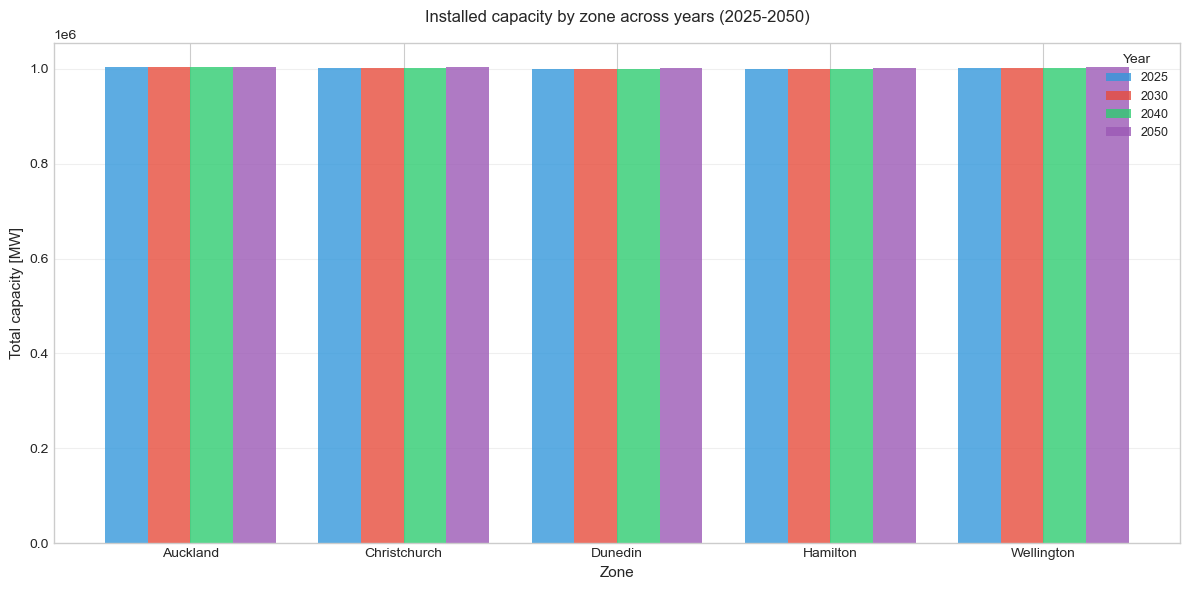


=== GROWTH BY ZONE ===

AUCKLAND:
  2025: 1003120.0 MW
  2030: 1003126.5 MW
  2040: 1003164.9 MW
  2050: 1004430.8 MW
  Growth 2025-2050: 1310.8 MW (0.1%)

CHRISTCHURCH:
  2025: 1001264.4 MW
  2030: 1001264.4 MW
  2040: 1001264.4 MW
  2050: 1003863.0 MW
  Growth 2025-2050: 2598.6 MW (0.3%)

DUNEDIN:
  2025: 1000682.4 MW
  2030: 1000694.0 MW
  2040: 1000697.9 MW
  2050: 1000962.5 MW
  Growth 2025-2050: 280.1 MW (0.0%)

HAMILTON:
  2025: 1000240.8 MW
  2030: 1000240.8 MW
  2040: 1000240.8 MW
  2050: 1001757.3 MW
  Growth 2025-2050: 1516.4 MW (0.2%)

WELLINGTON:
  2025: 1002628.8 MW
  2030: 1002628.8 MW
  2040: 1002628.8 MW
  2050: 1003737.7 MW
  Growth 2025-2050: 1109.0 MW (0.1%)


In [17]:
# Installed capacity comparison by zone across years
period_start = years[0]
period_end = years[-1]

# Extract capacities by zone and year
capacity_by_zone_year = {}
for year in years:
    net = all_results[year]['network']

    # Generators by zone
    gen_by_zone = net.generators.groupby(net.generators['bus'].str.replace('elec_', ''))['p_nom_opt'].sum()

    # Add BESS if present
    if len(net.storage_units) > 0:
        bess_by_zone = net.storage_units.groupby(net.storage_units['bus'].str.replace('elec_', ''))['p_nom_opt'].sum()
        gen_by_zone = gen_by_zone.add(bess_by_zone, fill_value=0)

    capacity_by_zone_year[year] = gen_by_zone

# Build DataFrame
cap_zone_df = pd.DataFrame(capacity_by_zone_year).fillna(0)

print("\n=== TOTAL CAPACITY BY ZONE AND YEAR [MW] ===")
display(cap_zone_df.round(2))

# Grouped bar chart by zone
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cap_zone_df.index))
width = 0.8 / len(years)
colors_years = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for i, year in enumerate(years):
    offset = width * (i - (len(years) - 1) / 2)
    ax.bar(x + offset, cap_zone_df[year], width, label=str(year),
           color=colors_years[i % len(colors_years)], alpha=0.8)

ax.set_title(f'Installed capacity by zone across years ({period_start}-{period_end})', fontsize=12, pad=15)
ax.set_ylabel('Total capacity [MW]', fontsize=11)
ax.set_xlabel('Zone', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([z.title() for z in cap_zone_df.index])
ax.legend(title='Year', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistics by zone
print("\n=== GROWTH BY ZONE ===")
for zone in cap_zone_df.index:
    growth = cap_zone_df.loc[zone, period_end] - cap_zone_df.loc[zone, period_start]
    growth_pct = (growth / cap_zone_df.loc[zone, period_start] * 100) if cap_zone_df.loc[zone, period_start] > 0 else 0
    print(f"\n{zone.upper()}:")
    for year in years:
        print(f"  {year}: {cap_zone_df.loc[zone, year]:.1f} MW")
    print(f"  Growth {period_start}-{period_end}: {growth:.1f} MW ({growth_pct:.1f}%)")

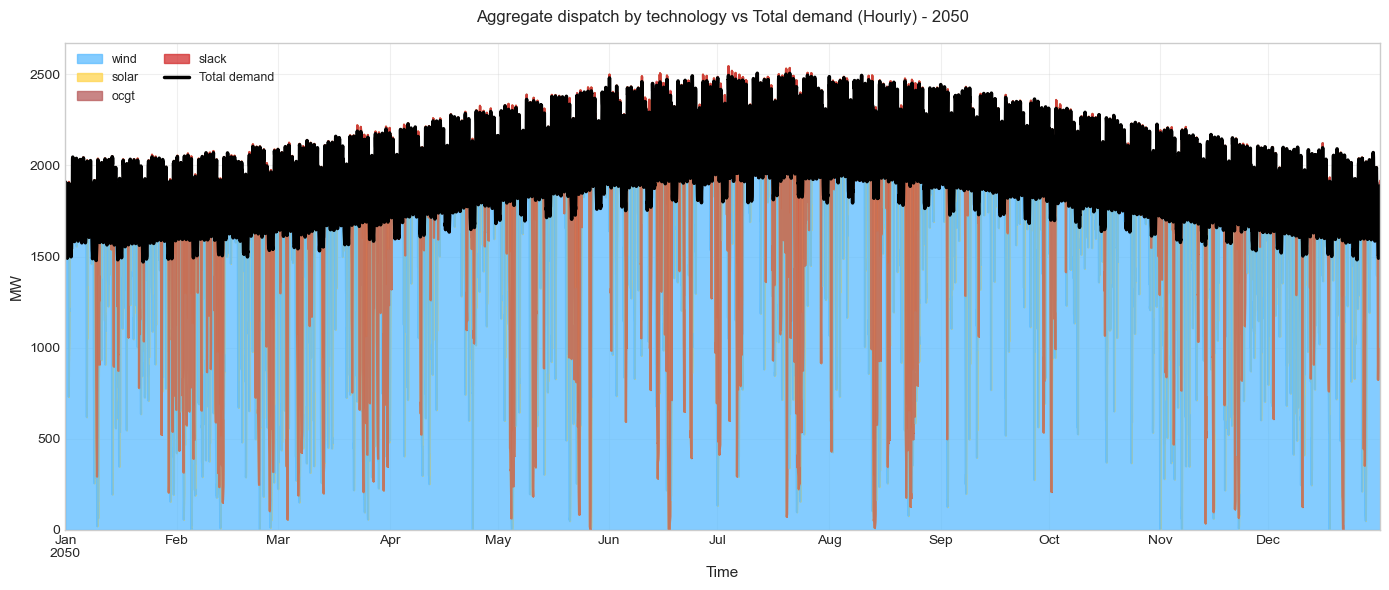

In [18]:
# Aggregate dispatch by technology vs total demand
analysis_year = detailed_year

dispatch = n.generators_t.p.copy()
dispatch_by_tech = dispatch.T.groupby(dispatch.T.index.str.split('_').str[0]).sum().T

# Clip small numerical negatives to zero to prevent area() plot errors
negative_techs = [
    tech for tech in dispatch_by_tech.columns
    if dispatch_by_tech[tech].min() < -1e-6
]
if negative_techs:
    print(f"Warning: negative values detected in {negative_techs}; clipping to 0 for plotting.")
dispatch_by_tech = dispatch_by_tech.clip(lower=0)

# BESS: separate charge and discharge per unit before aggregating
if len(n.storage_units) > 0:
    bess_power_by_unit = n.storage_units_t.p.copy()
    bess_discharge = bess_power_by_unit.clip(lower=0).sum(axis=1)
    bess_charge = -bess_power_by_unit.clip(upper=0).sum(axis=1)
    dispatch_by_tech['bess'] = bess_discharge
else:
    bess_charge = None

# Electricity output from hydrogen links (output at bus1)
if len(n.links) > 0:
    fuel_cell_links = n.links.index[n.links['carrier'] == 'h2_fuel_cell']
    if len(fuel_cell_links) > 0:
        dispatch_by_tech['h2_fuel_cell'] = (-n.links_t.p1[fuel_cell_links]).clip(lower=0).sum(axis=1)

    turbine_links = n.links.index[n.links['carrier'] == 'h2_turbine']
    if len(turbine_links) > 0:
        dispatch_by_tech['h2_turbine'] = (-n.links_t.p1[turbine_links]).clip(lower=0).sum(axis=1)

total_load = load.sum(axis=1)

# Consistent order and colors by technology
preferred_order = ['wind', 'solar', 'bess', 'h2_fuel_cell', 'h2_turbine', 'ocgt', 'gas', 'slack']
tech_order = [t for t in preferred_order if t in dispatch_by_tech.columns]
# Include any remaining techs not in the preferred order
tech_order += [t for t in dispatch_by_tech.columns if t not in tech_order]
dispatch_plot = dispatch_by_tech[tech_order]
tech_colors = [TECH_COLORS.get(t, '#999999') for t in tech_order]

fig, ax = plt.subplots(figsize=(14, 6))
dispatch_plot.plot.area(ax=ax, alpha=0.75, legend=True, color=tech_colors)

# Show BESS charging as negative area
if bess_charge is not None:
    ax.fill_between(bess_charge.index, 0, -bess_charge, alpha=0.3, color=TECH_COLORS['bess'],
                     label='BESS charging', step='mid')

total_load.plot(ax=ax, color='black', linewidth=2.5, label='Total demand', legend=True)

ax.set_title(f'Aggregate dispatch by technology vs Total demand (Hourly) - {analysis_year}', fontsize=12, pad=15)
ax.set_ylabel('MW', fontsize=11)
ax.set_xlabel('Time', fontsize=11)
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

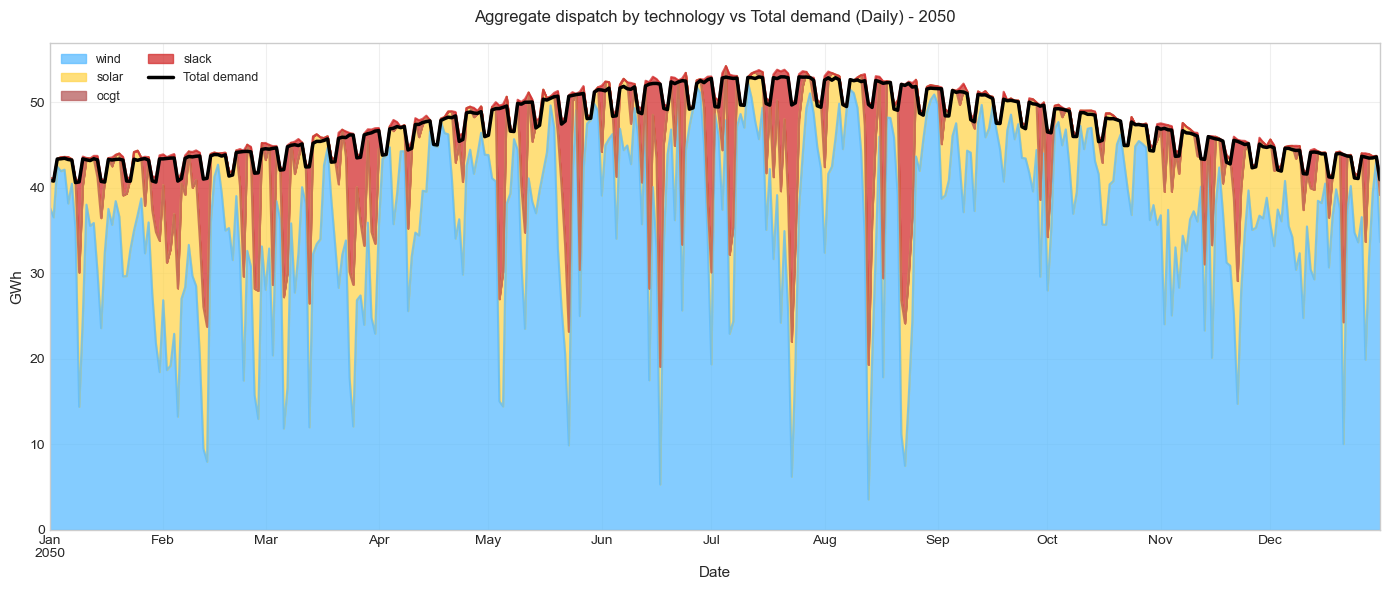

In [19]:
# --- Daily aggregated dispatch ---
dispatch_daily = dispatch_plot.resample('D').sum() / 1e3  # Convert MWh -> GWh
total_load_daily = total_load.resample('D').sum() / 1e3
bess_charge_daily = bess_charge.resample('D').sum() / 1e3 if bess_charge is not None else None

fig_d, ax_d = plt.subplots(figsize=(14, 6))
dispatch_daily.plot.area(ax=ax_d, alpha=0.75, legend=True, color=tech_colors)

if bess_charge_daily is not None:
    ax_d.fill_between(bess_charge_daily.index, 0, -bess_charge_daily, alpha=0.3,
                       color=TECH_COLORS['bess'], label='BESS charging')

total_load_daily.plot(ax=ax_d, color='black', linewidth=2.5, label='Total demand', legend=True)

ax_d.set_title(f'Aggregate dispatch by technology vs Total demand (Daily) - {analysis_year}', fontsize=12, pad=15)
ax_d.set_ylabel('GWh', fontsize=11)
ax_d.set_xlabel('Date', fontsize=11)
ax_d.legend(loc='upper left', ncol=2, fontsize=9)
ax_d.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

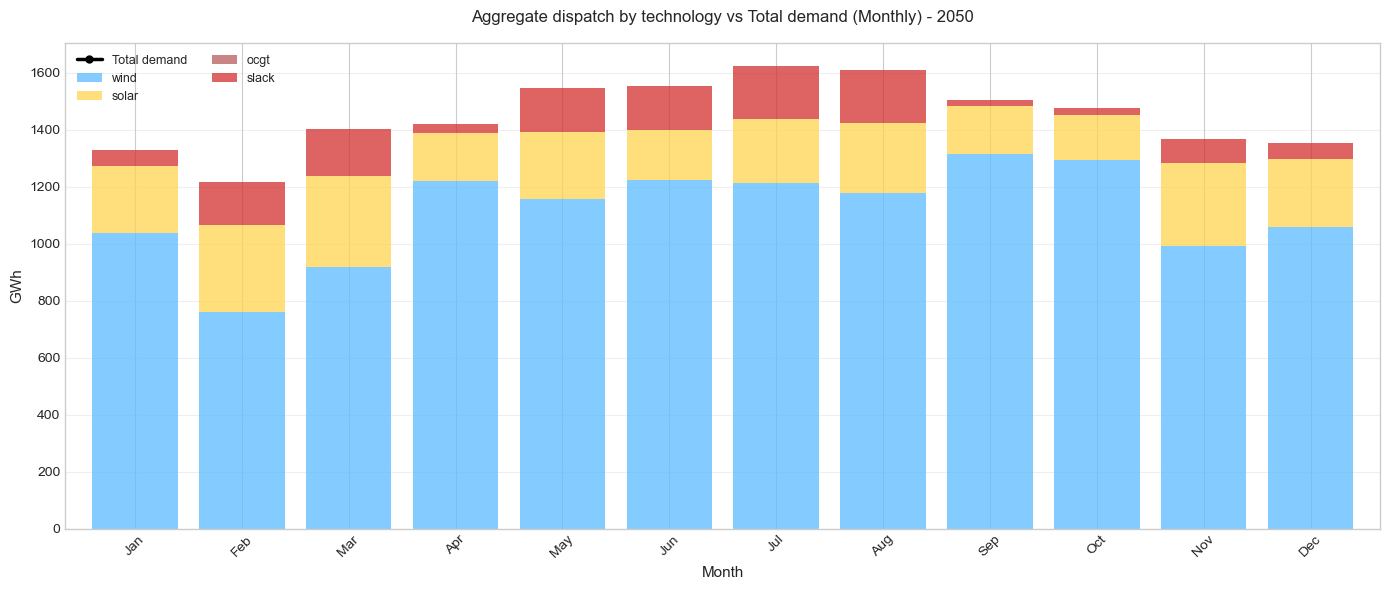

In [20]:
# --- Monthly aggregated dispatch ---
dispatch_monthly = dispatch_plot.resample('ME').sum() / 1e3  # Convert MWh -> GWh
total_load_monthly = total_load.resample('ME').sum() / 1e3
bess_charge_monthly = bess_charge.resample('ME').sum() / 1e3 if bess_charge is not None else None

fig_m, ax_m = plt.subplots(figsize=(14, 6))
dispatch_monthly.plot.bar(ax=ax_m, stacked=True, alpha=0.75, color=tech_colors, width=0.8)

if bess_charge_monthly is not None:
    ax_m.bar(range(len(bess_charge_monthly)), -bess_charge_monthly.values, alpha=0.3,
             color=TECH_COLORS['bess'], label='BESS charging', width=0.8)

ax_m.plot(range(len(total_load_monthly)), total_load_monthly.values, color='black',
          linewidth=2.5, marker='o', markersize=5, label='Total demand')

ax_m.set_title(f'Aggregate dispatch by technology vs Total demand (Monthly) - {analysis_year}', fontsize=12, pad=15)
ax_m.set_ylabel('GWh', fontsize=11)
ax_m.set_xlabel('Month', fontsize=11)
ax_m.set_xticklabels([d.strftime('%b') for d in dispatch_monthly.index], rotation=45)
ax_m.legend(loc='upper left', ncol=2, fontsize=9)
ax_m.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

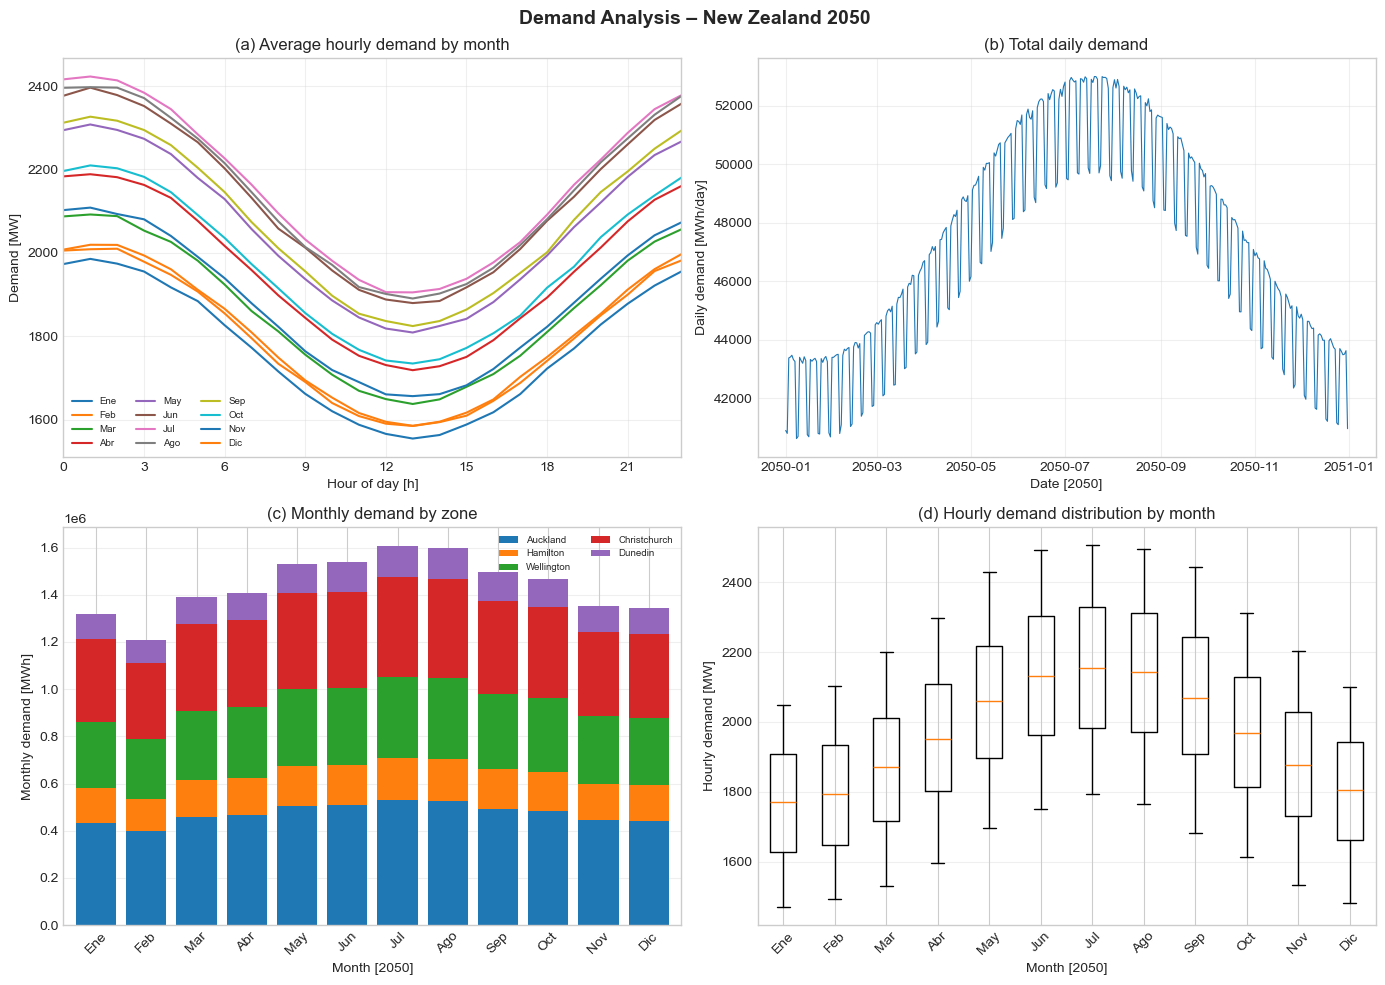

In [21]:
# ── Demand analysis (similar to demand_PArenas.py) ───────────────────────────
months_es = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
             7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

demand_ts = total_load.copy()
demand_ts.index = pd.to_datetime(demand_ts.index)
demand_month = demand_ts.index.month
demand_hour = demand_ts.index.hour

fig_dem, axes_dem = plt.subplots(2, 2, figsize=(14, 10))
fig_dem.suptitle(f"Demand Analysis – {case_name.replace('_', ' ').title()} {analysis_year}",
                 fontsize=14, fontweight="bold")

# --- (a) Average hourly demand curve by month ---
ax_a = axes_dem[0, 0]
for m in sorted(demand_ts.index.month.unique()):
    mask = demand_month == m
    hourly_avg = demand_ts[mask].groupby(demand_hour[mask]).mean()
    ax_a.plot(hourly_avg.index, hourly_avg.values, label=months_es.get(m, m))
ax_a.set_xlabel("Hour of day [h]")
ax_a.set_ylabel("Demand [MW]")
ax_a.set_title("(a) Average hourly demand by month")
ax_a.set_xlim(0, 23)
ax_a.set_xticks(range(0, 24, 3))
ax_a.legend(fontsize=7, ncol=3)
ax_a.grid(True, alpha=0.3)

# --- (b) Daily total demand over the year ---
ax_b = axes_dem[0, 1]
demand_daily_mwh = demand_ts.resample('D').sum()  # MWh/day
ax_b.plot(demand_daily_mwh.index, demand_daily_mwh.values, linewidth=0.8)
ax_b.set_xlabel(f"Date [{analysis_year}]")
ax_b.set_ylabel("Daily demand [MWh/day]")
ax_b.set_title("(b) Total daily demand")
ax_b.grid(True, alpha=0.3)

# --- (c) Monthly demand by zone (stacked bar) ---
ax_c = axes_dem[1, 0]
load_by_zone = load.copy()
load_by_zone.index = pd.to_datetime(load_by_zone.index)
load_by_zone['month'] = load_by_zone.index.month
monthly_by_zone = load_by_zone.groupby('month').sum()  # MWh per month
monthly_by_zone.index = [months_es.get(m, m) for m in monthly_by_zone.index]
# Simplify column names
monthly_by_zone.columns = [c.replace('elec_', '').replace('_', ' ').title() for c in monthly_by_zone.columns]
monthly_by_zone.plot(kind="bar", stacked=True, ax=ax_c, legend=True, width=0.8)
ax_c.set_xlabel(f"Month [{analysis_year}]")
ax_c.set_ylabel("Monthly demand [MWh]")
ax_c.set_title("(c) Monthly demand by zone")
ax_c.legend(fontsize=7, ncol=2, loc="upper right")
ax_c.tick_params(axis="x", rotation=45)
ax_c.grid(True, alpha=0.3, axis="y")

# --- (d) Boxplot of hourly demand by month ---
ax_d = axes_dem[1, 1]
data_box = [demand_ts[demand_month == m].values for m in sorted(demand_ts.index.month.unique())]
labels_box = [months_es.get(m, m) for m in sorted(demand_ts.index.month.unique())]
ax_d.boxplot(data_box, labels=labels_box, showfliers=False)
ax_d.set_xlabel(f"Month [{analysis_year}]")
ax_d.set_ylabel("Hourly demand [MW]")
ax_d.set_title("(d) Hourly demand distribution by month")
ax_d.tick_params(axis="x", rotation=45)
ax_d.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


=== ANNUAL CO2 EMISSIONS [tCO2] ===


,ocgt
2025,1654584.04
2030,1644365.34
2040,1640350.94


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


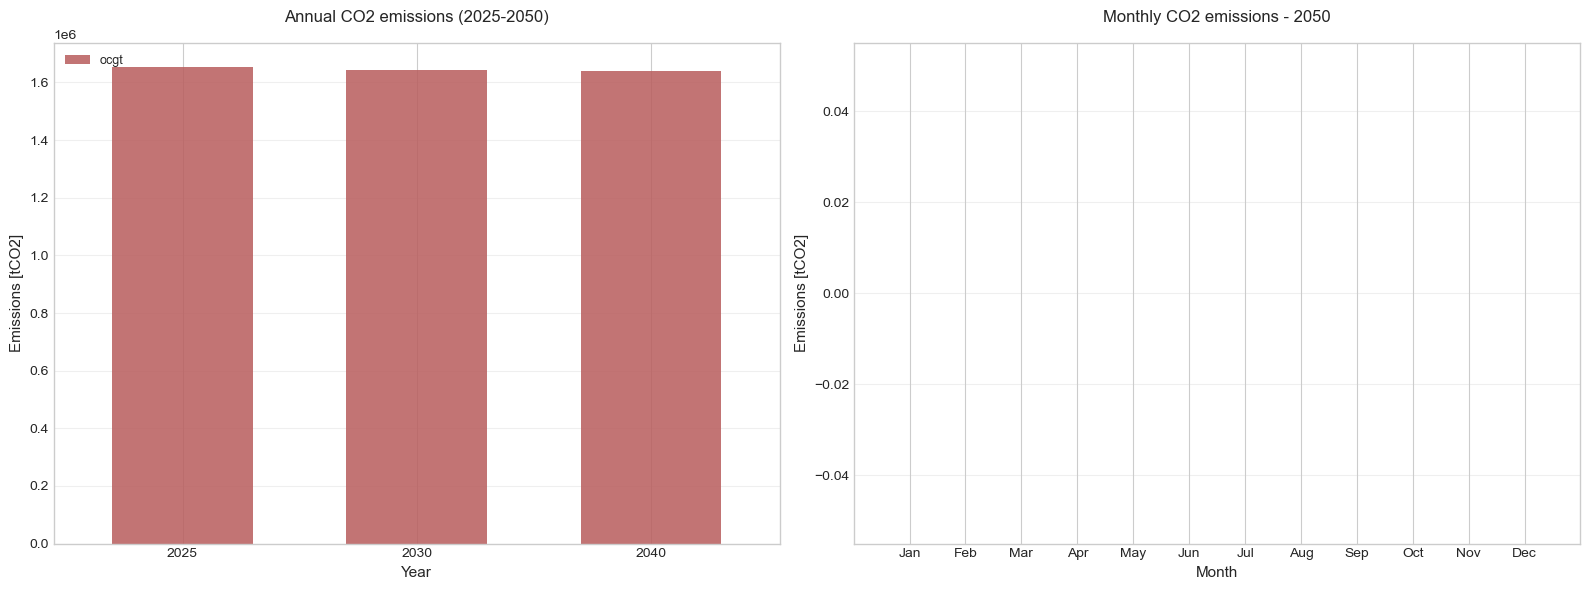


=== EMISSION INTENSITY [tCO2/MWh] ===
2025: 1654584.0 tCO2 | intensity = 0.0959 tCO2/MWh | status=ok, condition=optimal
2030: 1644365.3 tCO2 | intensity = 0.0953 tCO2/MWh | status=ok, condition=optimal
2040: 1640350.9 tCO2 | intensity = 0.0948 tCO2/MWh | status=ok, condition=optimal
2050: 0.0 tCO2 | intensity = 0.0000 tCO2/MWh | status=ok, condition=optimal


In [22]:
# CO2 emissions using native emission factors loaded into PyPSA (carrier.co2_emissions)
import numpy as np
import pandas as pd

annual_emissions_total = {}
annual_emissions_by_carrier = {}
annual_loads = {}
monthly_emissions_detail = None
year_status = {}

for year in years:
    net = all_results[year]['network']
    status = str(all_results[year].get('status', 'unknown')).lower()
    condition = str(all_results[year].get('condition', 'unknown')).lower()
    year_status[year] = (status, condition)

    # Annual total demand
    year_load = all_results[year]['load'].sum(axis=1)
    annual_loads[year] = float(year_load.sum())

    # If no usable solution, record zero and continue
    if status not in {'ok', 'optimal'} and condition not in {'optimal', 'feasible'}:
        annual_emissions_total[year] = 0.0
        annual_emissions_by_carrier[year] = {}
        if year == detailed_year:
            monthly_emissions_detail = pd.Series(dtype=float)
        continue

    # Emission factors by carrier [tCO2/MWh_th]
    carrier_factors = (
        net.carriers['co2_emissions'] if 'co2_emissions' in net.carriers.columns
        else pd.Series(dtype=float)
    )
    carrier_factors = carrier_factors.fillna(0.0)

    # Align dispatch to all generators to avoid KeyError
    dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)

    # Electrical emission factor per generator: (tCO2/MWh_th) / efficiency = tCO2/MWh_el
    gen_carrier = net.generators['carrier'].astype(str)
    gen_eff = net.generators['efficiency'].replace(0, np.nan).fillna(1.0)
    gen_emission_factor_el = gen_carrier.map(carrier_factors).fillna(0.0) / gen_eff
    gen_emission_factor_el = gen_emission_factor_el.fillna(0.0)

    emissions_by_gen_ts = dispatch.multiply(gen_emission_factor_el, axis=1)
    total_emissions_year = float(emissions_by_gen_ts.to_numpy().sum())
    annual_emissions_total[year] = total_emissions_year

    # Aggregation by carrier
    emissions_by_carrier_year = {}
    for carrier in sorted(gen_carrier.unique()):
        cols = gen_carrier.index[gen_carrier == carrier]
        value = float(emissions_by_gen_ts[cols].to_numpy().sum()) if len(cols) > 0 else 0.0
        if value > 0:
            emissions_by_carrier_year[carrier] = value
    annual_emissions_by_carrier[year] = emissions_by_carrier_year

    if year == detailed_year:
        monthly_emissions_detail = emissions_by_gen_ts.sum(axis=1).resample('ME').sum()

# Output DataFrames
emissions_df = pd.DataFrame.from_dict(annual_emissions_by_carrier, orient='index').fillna(0.0).sort_index()
total_emissions_series = pd.Series(annual_emissions_total).sort_index()

print('\n=== ANNUAL CO2 EMISSIONS [tCO2] ===')
display(emissions_df.round(2) if not emissions_df.empty else pd.DataFrame(index=years))

emissions_intensity = pd.Series({
    year: (total_emissions_series.loc[year] / annual_loads[year]) if annual_loads[year] > 0 else 0.0
    for year in total_emissions_series.index
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if not emissions_df.empty and emissions_df.sum().sum() > 0:
    emission_colors = [TECH_COLORS.get(t, '#666666') for t in emissions_df.columns]
    emissions_df.plot.bar(ax=axes[0], stacked=True, color=emission_colors, alpha=0.85, width=0.6)
    axes[0].legend(loc='upper left', fontsize=9)
else:
    total_emissions_series.plot.bar(ax=axes[0], color='#666666', alpha=0.85, width=0.6)
    axes[0].legend().remove() if axes[0].get_legend() is not None else None

axes[0].set_title(f'Annual CO2 emissions ({years[0]}-{years[-1]})', fontsize=12, pad=15)
axes[0].set_ylabel('Emissions [tCO2]', fontsize=11)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

if monthly_emissions_detail is not None and len(monthly_emissions_detail) > 0:
    month_labels = [ts.strftime('%b') for ts in monthly_emissions_detail.index]
    axes[1].bar(month_labels, monthly_emissions_detail.values, color=TECH_COLORS.get('ocgt', '#666666'), alpha=0.85)
    axes[1].set_ylabel('Emissions [tCO2]', fontsize=11)
    axes[1].set_xlabel('Month', fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No emissions or infeasible year', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()

axes[1].set_title(f'Monthly CO2 emissions - {detailed_year}', fontsize=12, pad=15)

plt.tight_layout()
plt.show()

print('\n=== EMISSION INTENSITY [tCO2/MWh] ===')
for year in total_emissions_series.index:
    total_emissions = total_emissions_series.loc[year]
    status, condition = year_status[year]
    print(f"{year}: {total_emissions:.1f} tCO2 | intensity = {emissions_intensity.loc[year]:.4f} tCO2/MWh | status={status}, condition={condition}")

if detailed_year in emissions_df.index and emissions_df.loc[detailed_year].sum() > 0:
    print(f'\n=== DETAIL {detailed_year} ===')
    for tech, value in emissions_df.loc[detailed_year].items():
        if value > 0:
            print(f'{tech}: {value:.1f} tCO2')

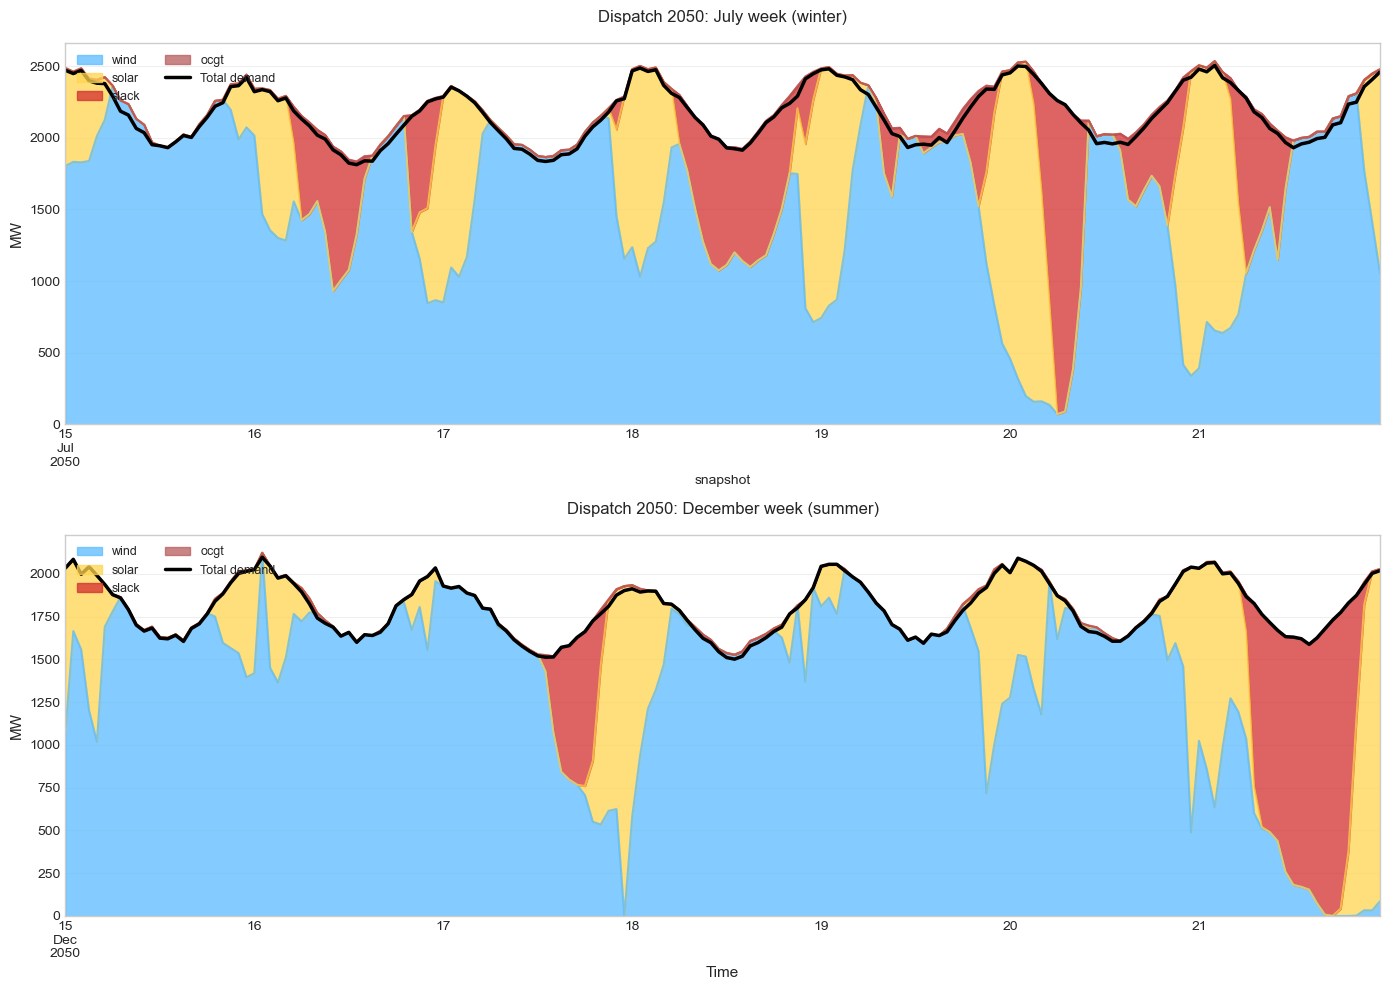


=== JULY vs DECEMBER COMPARISON (2050) ===

July (winter):
  Avg demand: 2167.8 MW | peak: 2505.5 MW
  wind avg: 1528.4 MW
  solar avg: 402.9 MW
  slack avg: 264.5 MW
  ocgt avg: 0.0 MW

December (summer):
  Avg demand: 1800.0 MW | peak: 2097.0 MW
  wind avg: 1390.3 MW
  solar avg: 270.7 MW
  slack avg: 146.8 MW
  ocgt avg: 0.0 MW


In [23]:
# Weekly dispatch zoom: July (winter) and December (summer)
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Color fallback in case this cell runs without cell 2
if 'TECH_COLORS' not in globals():
    TECH_COLORS = {
        'wind': '#5bbcff',
        'solar': '#ffd54f',
        'ocgt': '#b85c5c',
        'bess': '#9966cc',
        'h2_fuel_cell': '#ff8f00',
        'h2_turbine': '#6d4c41',
        'slack': '#d32f2f',
        'natural_gas': '#bdbdbd',
        'gas': '#bdbdbd',
    }

# Ensure DatetimeIndex to avoid empty windows from format mismatch
if not isinstance(dispatch_by_tech.index, pd.DatetimeIndex):
    dispatch_by_tech = dispatch_by_tech.copy()
    dispatch_by_tech.index = pd.to_datetime(dispatch_by_tech.index)

if not isinstance(total_load.index, pd.DatetimeIndex):
    total_load = total_load.copy()
    total_load.index = pd.to_datetime(total_load.index)

analysis_year = int(total_load.index[0].year)

def _select_week(data, month, take='first'):
    """Return a representative week from the requested month with robust fallback."""
    start = f"{analysis_year}-{month:02d}-15"
    end = f"{analysis_year}-{month:02d}-21 23:00"
    window = data.loc[start:end]

    if window.empty:
        month_data = data[data.index.month == month]
        if len(month_data) >= 24 * 7:
            window = month_data.iloc[:24 * 7] if take == 'first' else month_data.iloc[-24 * 7:]
        else:
            window = month_data

    if window.empty:
        fallback_rows = min(len(data), 24 * 7)
        window = data.iloc[:fallback_rows] if take == 'first' else data.iloc[-fallback_rows:]

    return window

# July week (winter in Southern Hemisphere)
dispatch_july = _select_week(dispatch_by_tech, month=7, take='first')
load_july = _select_week(total_load.to_frame('load'), month=7, take='first')['load']

# Sort columns by average contribution (highest first)
col_order_july = dispatch_july.mean().sort_values(ascending=False).index
dispatch_july_sorted = dispatch_july[col_order_july]
july_colors = [TECH_COLORS.get(t, '#999999') for t in col_order_july]

if dispatch_july_sorted.empty:
    raise ValueError('No dispatch data available for the July window.')

dispatch_july_sorted.plot.area(ax=axes[0], alpha=0.75, legend=True, color=july_colors)
load_july.plot(ax=axes[0], color='black', linewidth=2.5, label='Total demand', legend=True)
axes[0].set_title(f'Dispatch {analysis_year}: July week (winter)', fontsize=12, pad=15)
axes[0].set_ylabel('MW', fontsize=11)
axes[0].legend(loc='upper left', ncol=2, fontsize=9)
axes[0].grid(True, alpha=0.3)

# December week (summer in Southern Hemisphere)
dispatch_dec = _select_week(dispatch_by_tech, month=12, take='last')
load_dec = _select_week(total_load.to_frame('load'), month=12, take='last')['load']

# Sort columns by average contribution (highest first)
col_order_dec = dispatch_dec.mean().sort_values(ascending=False).index
dispatch_dec_sorted = dispatch_dec[col_order_dec]
dec_colors = [TECH_COLORS.get(t, '#999999') for t in col_order_dec]

if dispatch_dec_sorted.empty:
    raise ValueError('No dispatch data available for the December window.')

dispatch_dec_sorted.plot.area(ax=axes[1], alpha=0.75, legend=True, color=dec_colors)
load_dec.plot(ax=axes[1], color='black', linewidth=2.5, label='Total demand', legend=True)
axes[1].set_title(f'Dispatch {analysis_year}: December week (summer)', fontsize=12, pad=15)
axes[1].set_ylabel('MW', fontsize=11)
axes[1].set_xlabel('Time', fontsize=11)
axes[1].legend(loc='upper left', ncol=2, fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparative statistics
print(f"\n=== JULY vs DECEMBER COMPARISON ({analysis_year}) ===")
print(f"\nJuly (winter):")
print(f"  Avg demand: {load_july.mean():.1f} MW | peak: {load_july.max():.1f} MW")
for tech in col_order_july:
    print(f"  {tech} avg: {dispatch_july[tech].mean():.1f} MW")

print(f"\nDecember (summer):")
print(f"  Avg demand: {load_dec.mean():.1f} MW | peak: {load_dec.max():.1f} MW")
for tech in col_order_dec:
    print(f"  {tech} avg: {dispatch_dec[tech].mean():.1f} MW")

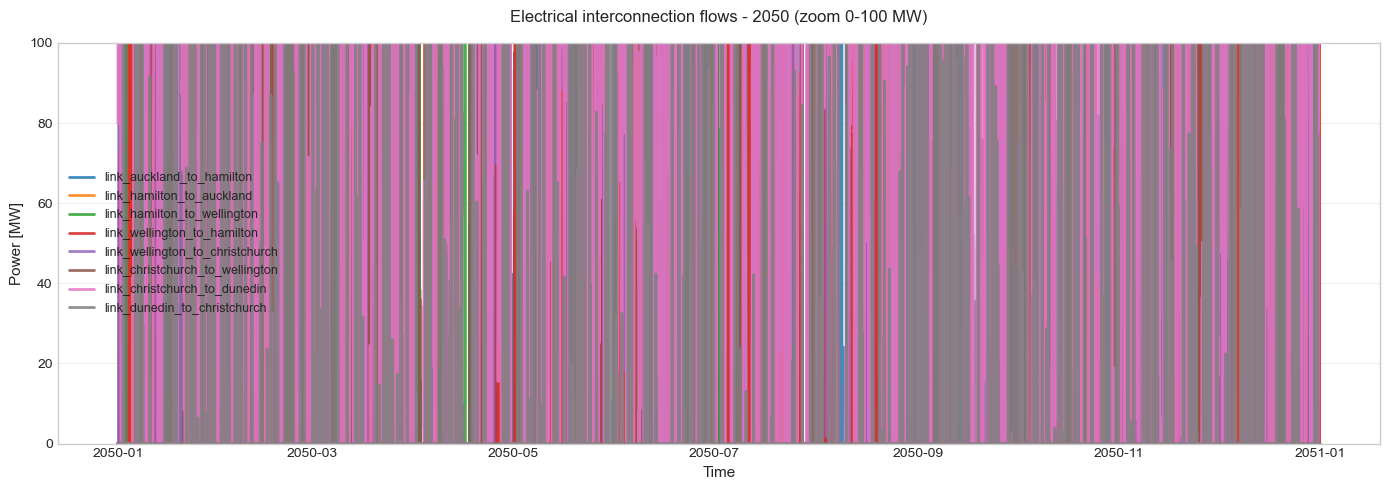


=== ELECTRICAL FLOWS (2050) ===
link_auckland_to_hamilton:  avg=33.3 MW | max=1172.9 MW | min=-0.0 MW
link_hamilton_to_auckland:  avg=93.6 MW | max=820.2 MW | min=-0.0 MW
link_hamilton_to_wellington:  avg=38.2 MW | max=1183.8 MW | min=-0.0 MW
link_wellington_to_hamilton:  avg=142.6 MW | max=1060.5 MW | min=-0.0 MW
link_wellington_to_christchurch:  avg=126.8 MW | max=893.4 MW | min=-0.0 MW
link_christchurch_to_wellington:  avg=22.8 MW | max=1200.0 MW | min=-0.0 MW
link_christchurch_to_dunedin:  avg=45.6 MW | max=215.7 MW | min=-0.0 MW
link_dunedin_to_christchurch:  avg=37.4 MW | max=652.2 MW | min=-0.0 MW
No active H2/UHS links in the network.


In [24]:
# Link flows: electrical interconnections and H2/UHS links (separate plots)
analysis_year = detailed_year
links_flow = n.links_t.p0.copy()

# Separate by type
elec_links = [c for c in links_flow.columns if str(c).startswith('link_')]
h2_uhs_carriers = {'electrolyzer', 'h2_fuel_cell', 'h2_turbine', 'uhs_injection', 'uhs_withdrawal'}
h2_links = [
    c for c in links_flow.columns
    if c in n.links.index and n.links.loc[c, 'carrier'] in h2_uhs_carriers
]

# ── Figure 1: electrical interconnections (Y-axis capped at 0-100 MW) ──────
if elec_links:
    fig, ax = plt.subplots(figsize=(14, 5))
    for link in elec_links:
        ax.plot(links_flow.index, links_flow[link], linewidth=2, label=link, alpha=0.85)
    ax.set_title(f'Electrical interconnection flows - {analysis_year} (zoom 0-100 MW)',
                 fontsize=12, pad=15)
    ax.set_ylabel('Power [MW]', fontsize=11)
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n=== ELECTRICAL FLOWS ({analysis_year}) ===')
    for link in elec_links:
        f = links_flow[link]
        print(f'{link}:  avg={f.mean():.1f} MW | max={f.max():.1f} MW | min={f.min():.1f} MW')
else:
    print('No electrical interconnections (link_*) found in the network.')

# ── Figure 2: H2/UHS links ────────────────────────────────────────────────
if h2_links:
    h2_color_map = {
        'electrolyzer':    TECH_COLORS.get('electrolyzer', '#00897b'),
        'h2_fuel_cell':    TECH_COLORS.get('h2_fuel_cell', '#ff8f00'),
        'h2_turbine':      TECH_COLORS.get('h2_turbine',   '#6d4c41'),
        'uhs_injection':   TECH_COLORS.get('uhs_injection', '#1e88e5'),
        'uhs_withdrawal':  TECH_COLORS.get('uhs_withdrawal', '#3949ab'),
    }
    fig, ax = plt.subplots(figsize=(14, 5))
    for link in h2_links:
        carrier = n.links.loc[link, 'carrier']
        ax.plot(
            links_flow.index,
            links_flow[link],
            linewidth=1.8,
            label=f"{link} ({carrier})",
            alpha=0.85,
            color=h2_color_map.get(carrier, '#999')
        )
    ax.set_title(f'Hydrogen/UHS link flows - {analysis_year}', fontsize=12, pad=15)
    ax.set_ylabel('Power [MW]', fontsize=11)
    ax.set_xlabel('Time', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n=== H2/UHS FLOWS ({analysis_year}) ===')
    for link in h2_links:
        carrier = n.links.loc[link, 'carrier']
        f = links_flow[link]
        print(f'{link} ({carrier}):  avg={f.mean():.1f} MW | max={f.max():.1f} MW | min={f.min():.1f} MW')
else:
    print('No active H2/UHS links in the network.')

In [25]:
# BESS (Battery Energy Storage System) analysis
analysis_year = detailed_year

if len(n.storage_units) > 0:
    print(f"\n=== INSTALLED BESS CAPACITIES ({analysis_year}) ===")
    bess_caps = n.storage_units[['bus', 'p_nom_opt', 'max_hours']].copy()
    bess_caps['energy_capacity_MWh'] = bess_caps['p_nom_opt'] * bess_caps['max_hours']
    bess_caps = bess_caps.sort_values('p_nom_opt', ascending=False)
    display(bess_caps)

    # Separate charge and discharge per unit before aggregating to avoid cancellations
    bess_power_by_unit = n.storage_units_t.p.copy()
    bess_discharge = bess_power_by_unit.clip(lower=0).sum(axis=1)
    bess_charge = -bess_power_by_unit.clip(upper=0).sum(axis=1)
    bess_net_power = bess_discharge - bess_charge
    bess_soc = n.storage_units_t.state_of_charge.sum(axis=1)

    # Color fallback
    if 'TECH_COLORS' not in globals():
        TECH_COLORS = {'bess': '#9966cc'}

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    # Plot 1: Aggregate charge/discharge power
    axes[0].fill_between(bess_discharge.index, 0, bess_discharge,
                         color=TECH_COLORS.get('bess', '#9966cc'),
                         alpha=0.7, label='Discharge (generation)', step='mid')
    axes[0].fill_between(bess_charge.index, 0, -bess_charge,
                         color=TECH_COLORS.get('bess', '#9966cc'),
                         alpha=0.4, label='Charge (consumption)', step='mid')
    axes[0].axhline(y=0, color='black', linewidth=1)
    axes[0].set_title(f'BESS {analysis_year}: charge/discharge power', fontsize=12, pad=15)
    axes[0].set_ylabel('Power [MW]', fontsize=11)
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: State of charge (SOC)
    axes[1].plot(bess_soc.index, bess_soc, color=TECH_COLORS.get('bess', '#9966cc'),
                 linewidth=2, label='State of charge')
    axes[1].fill_between(bess_soc.index, 0, bess_soc,
                         color=TECH_COLORS.get('bess', '#9966cc'), alpha=0.3)
    axes[1].set_title(f'BESS {analysis_year}: state of charge (SOC)', fontsize=12, pad=15)
    axes[1].set_ylabel('Stored energy [MWh]', fontsize=11)
    axes[1].set_xlabel('Time', fontsize=11)
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"\n=== BESS OPERATION STATISTICS ({analysis_year}) ===")
    print(f"Total installed capacity: {bess_caps['p_nom_opt'].sum():.2f} MW")
    print(f"Total energy capacity: {bess_caps['energy_capacity_MWh'].sum():.2f} MWh")
    print(f"\nPower:")
    print(f"  Peak discharge: {bess_discharge.max():.2f} MW")
    print(f"  Peak charge: {bess_charge.max():.2f} MW")
    print(f"  Avg discharge: {bess_discharge[bess_discharge > 0].mean():.2f} MW")
    print(f"  Avg charge: {bess_charge[bess_charge > 0].mean():.2f} MW")
    print(f"  Avg net power: {bess_net_power.mean():.2f} MW")
    print(f"\nEnergy:")
    print(f"  SOC max: {bess_soc.max():.2f} MWh")
    print(f"  SOC avg: {bess_soc.mean():.2f} MWh")
    print(f"  SOC min: {bess_soc.min():.2f} MWh")

    # Cycle analysis
    charge_energy = bess_charge.sum()
    discharge_energy = bess_discharge.sum()
    print(f"\nAnnual energy:")
    print(f"  Charged: {charge_energy:.0f} MWh")
    print(f"  Discharged: {discharge_energy:.0f} MWh")
    print(f"  Round-trip efficiency: {(discharge_energy / charge_energy * 100):.1f}%" if charge_energy > 0 else "  Round-trip efficiency: n/a")
else:
    print(f"No storage units (BESS) in the network for {analysis_year}.")

No storage units (BESS) in the network for 2050.


In [26]:
# Hydrogen/UHS analysis: conversion and storage
import pandas as pd

analysis_year = detailed_year
hydrogen_link_carriers = ['electrolyzer', 'h2_fuel_cell', 'h2_turbine', 'uhs_injection', 'uhs_withdrawal']
hydrogen_store_carriers = ['hydrogen_storage', 'uhs_storage']

hydrogen_links = n.links[n.links['carrier'].isin(hydrogen_link_carriers)].copy()
hydrogen_stores = n.stores[n.stores['carrier'].isin(hydrogen_store_carriers)].copy()

if hydrogen_links.empty and hydrogen_stores.empty:
    print(
        f"No hydrogen/UHS assets in the network for {analysis_year}. "
        f"enable_hydrogen={all_results[analysis_year].get('enable_hydrogen', True)}."
    )
else:
    if 'TECH_COLORS' not in globals():
        TECH_COLORS = {
            'electrolyzer': '#00897b',
            'h2_fuel_cell': '#ff8f00',
            'h2_turbine': '#6d4c41',
            'hydrogen_storage': '#26a69a',
            'uhs_injection': '#1e88e5',
            'uhs_withdrawal': '#3949ab',
            'uhs_storage': '#8e24aa',
        }

    H2_LHV_MWH_PER_TON = 33.33  # MWh per tonne of H2 (lower heating value)

    def _zero_series() -> pd.Series:
        """Return a zero-valued series aligned with the network snapshots."""
        return pd.Series(0.0, index=n.snapshots)

    def _link_input_series(link_index: pd.Index) -> pd.Series:
        """Aggregate electricity input (p0) for the given link indices."""
        if len(link_index) == 0:
            return _zero_series()
        return n.links_t.p0[link_index].clip(lower=0).sum(axis=1)

    def _link_output_series(link_index: pd.Index) -> pd.Series:
        """Aggregate useful output (p0 * efficiency) for the given link indices."""
        if len(link_index) == 0:
            return _zero_series()
        efficiency = n.links.loc[link_index, 'efficiency'].fillna(1.0)
        dispatch = n.links_t.p0[link_index].clip(lower=0)
        return dispatch.multiply(efficiency, axis=1).sum(axis=1)

    electrolyzer_links = hydrogen_links.index[hydrogen_links['carrier'] == 'electrolyzer']
    fuel_cell_links = hydrogen_links.index[hydrogen_links['carrier'] == 'h2_fuel_cell']
    turbine_links = hydrogen_links.index[hydrogen_links['carrier'] == 'h2_turbine']
    uhs_injection_links = hydrogen_links.index[hydrogen_links['carrier'] == 'uhs_injection']
    uhs_withdrawal_links = hydrogen_links.index[hydrogen_links['carrier'] == 'uhs_withdrawal']

    electrolyzer_power = _link_input_series(electrolyzer_links)
    hydrogen_production = _link_output_series(electrolyzer_links)
    fuel_cell_power = _link_output_series(fuel_cell_links)
    turbine_power = _link_output_series(turbine_links)
    hydrogen_to_power = fuel_cell_power + turbine_power
    hydrogen_reconversion_input = _link_input_series(fuel_cell_links) + _link_input_series(turbine_links)

    uhs_injection_power = _link_input_series(uhs_injection_links)
    uhs_withdrawal_power = _link_output_series(uhs_withdrawal_links)

    tank_stores = hydrogen_stores.index[hydrogen_stores['carrier'] == 'hydrogen_storage']
    uhs_stores = hydrogen_stores.index[hydrogen_stores['carrier'] == 'uhs_storage']

    tank_inventory = _zero_series() if len(tank_stores) == 0 else n.stores_t.e[tank_stores].sum(axis=1)
    uhs_inventory = _zero_series() if len(uhs_stores) == 0 else n.stores_t.e[uhs_stores].sum(axis=1)
    hydrogen_inventory = tank_inventory + uhs_inventory

    # Tonnes conversion
    tank_inventory_ton = tank_inventory / H2_LHV_MWH_PER_TON
    uhs_inventory_ton = uhs_inventory / H2_LHV_MWH_PER_TON
    hydrogen_inventory_ton = hydrogen_inventory / H2_LHV_MWH_PER_TON

    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

    # Panel 1: H2 production and UHS injection
    axes[0].fill_between(
        electrolyzer_power.index, 0, electrolyzer_power,
        color=TECH_COLORS.get('electrolyzer', '#00897b'), alpha=0.65,
        label='Electrolyzer electricity input', step='mid'
    )
    axes[0].plot(
        hydrogen_production.index, hydrogen_production,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), linewidth=1.8,
        label='Hydrogen production',
    )
    axes[0].fill_between(
        uhs_injection_power.index, 0, uhs_injection_power,
        color=TECH_COLORS.get('uhs_injection', '#1e88e5'), alpha=0.35,
        label='UHS injection (H2 -> UHS)', step='mid'
    )
    axes[0].set_title(f'Hydrogen/UHS operation {analysis_year}: production and UHS injection', fontsize=12, pad=15)
    axes[0].set_ylabel('MW / MWh/h', fontsize=11)
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Power reconversion and UHS withdrawal
    axes[1].fill_between(
        fuel_cell_power.index, 0, fuel_cell_power,
        color=TECH_COLORS.get('h2_fuel_cell', '#ff8f00'), alpha=0.65,
        label='Fuel cell electricity output', step='mid'
    )
    axes[1].fill_between(
        turbine_power.index, fuel_cell_power, hydrogen_to_power,
        color=TECH_COLORS.get('h2_turbine', '#6d4c41'), alpha=0.65,
        label='H2 turbine electricity output', step='mid'
    )
    axes[1].plot(
        hydrogen_reconversion_input.index, hydrogen_reconversion_input,
        color='black', linewidth=1.5, linestyle='--',
        label='Hydrogen input to reconversion'
    )
    axes[1].plot(
        uhs_withdrawal_power.index, uhs_withdrawal_power,
        color=TECH_COLORS.get('uhs_withdrawal', '#3949ab'), linewidth=1.7,
        label='UHS withdrawal (UHS -> H2)'
    )
    axes[1].set_title(f'Hydrogen/UHS operation {analysis_year}: power reconversion and UHS withdrawal', fontsize=12, pad=15)
    axes[1].set_ylabel('MW / MWh/h', fontsize=11)
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Storage inventory levels [MWh]
    axes[2].plot(
        tank_inventory.index, tank_inventory,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), linewidth=2,
        label='Tank inventory'
    )
    axes[2].plot(
        uhs_inventory.index, uhs_inventory,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), linewidth=2,
        label='UHS inventory'
    )
    axes[2].plot(
        hydrogen_inventory.index, hydrogen_inventory,
        color='black', linewidth=1.4, linestyle='--',
        label='Total H2 inventory'
    )
    axes[2].fill_between(
        tank_inventory.index, 0, tank_inventory,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), alpha=0.2
    )
    axes[2].fill_between(
        uhs_inventory.index, 0, uhs_inventory,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), alpha=0.15
    )
    axes[2].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory', fontsize=12, pad=15)
    axes[2].set_ylabel('Stored energy [MWh]', fontsize=11)
    axes[2].legend(loc='best', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    # Panel 4: Storage inventory levels [tonnes H2]
    axes[3].plot(
        tank_inventory_ton.index, tank_inventory_ton,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), linewidth=2,
        label='Tank inventory'
    )
    axes[3].plot(
        uhs_inventory_ton.index, uhs_inventory_ton,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), linewidth=2,
        label='UHS inventory'
    )
    axes[3].plot(
        hydrogen_inventory_ton.index, hydrogen_inventory_ton,
        color='black', linewidth=1.4, linestyle='--',
        label='Total H2 inventory'
    )
    axes[3].fill_between(
        tank_inventory_ton.index, 0, tank_inventory_ton,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), alpha=0.2
    )
    axes[3].fill_between(
        uhs_inventory_ton.index, 0, uhs_inventory_ton,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), alpha=0.15
    )
    axes[3].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory (LHV = {H2_LHV_MWH_PER_TON} MWh/t)', fontsize=12, pad=15)
    axes[3].set_ylabel('Stored hydrogen [ton]', fontsize=11)
    axes[3].set_xlabel('Time', fontsize=11)
    axes[3].legend(loc='best', fontsize=9)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Display link capacities
    link_capacity_column = 'p_nom_opt' if 'p_nom_opt' in hydrogen_links.columns else 'p_nom'
    link_caps = hydrogen_links[['carrier', 'bus0', 'bus1', 'efficiency']].copy()
    link_caps['capacity_mw'] = hydrogen_links[link_capacity_column]
    print(f"\n=== HYDROGEN/UHS LINK CAPACITIES ({analysis_year}) ===")
    display(link_caps.sort_values(['carrier', 'capacity_mw'], ascending=[True, False]))

    # Display store capacities
    if not hydrogen_stores.empty:
        store_capacity_column = 'e_nom_opt' if 'e_nom_opt' in hydrogen_stores.columns else 'e_nom'
        store_caps = hydrogen_stores[['carrier', 'bus', 'standing_loss']].copy()
        store_caps['energy_capacity_mwh'] = hydrogen_stores[store_capacity_column]
        print(f"\n=== HYDROGEN/UHS STORAGE CAPACITIES ({analysis_year}) ===")
        display(store_caps.sort_values(['carrier', 'energy_capacity_mwh'], ascending=[True, False]))

    print(f"\n=== HYDROGEN/UHS OPERATION STATISTICS ({analysis_year}) ===")
    print(f"Electrolyzer electricity input: {electrolyzer_power.sum():,.0f} MWh")
    print(f"Hydrogen production: {hydrogen_production.sum():,.0f} MWh")
    print(f"UHS injection (H2 -> UHS): {uhs_injection_power.sum():,.0f} MWh")
    print(f"UHS withdrawal (UHS -> H2): {uhs_withdrawal_power.sum():,.0f} MWh")
    print(f"Hydrogen input to reconversion: {hydrogen_reconversion_input.sum():,.0f} MWh")
    print(f"Electricity from fuel cells: {fuel_cell_power.sum():,.0f} MWh")
    print(f"Electricity from H2 turbines: {turbine_power.sum():,.0f} MWh")
    print(f"Peak tank inventory: {tank_inventory.max():,.2f} MWh  ({tank_inventory_ton.max():,.2f} ton)")
    print(f"Peak UHS inventory: {uhs_inventory.max():,.2f} MWh  ({uhs_inventory_ton.max():,.2f} ton)")
    print(f"Peak total H2 inventory: {hydrogen_inventory.max():,.2f} MWh  ({hydrogen_inventory_ton.max():,.2f} ton)")


No hydrogen/UHS assets in the network for 2050. enable_hydrogen=True.


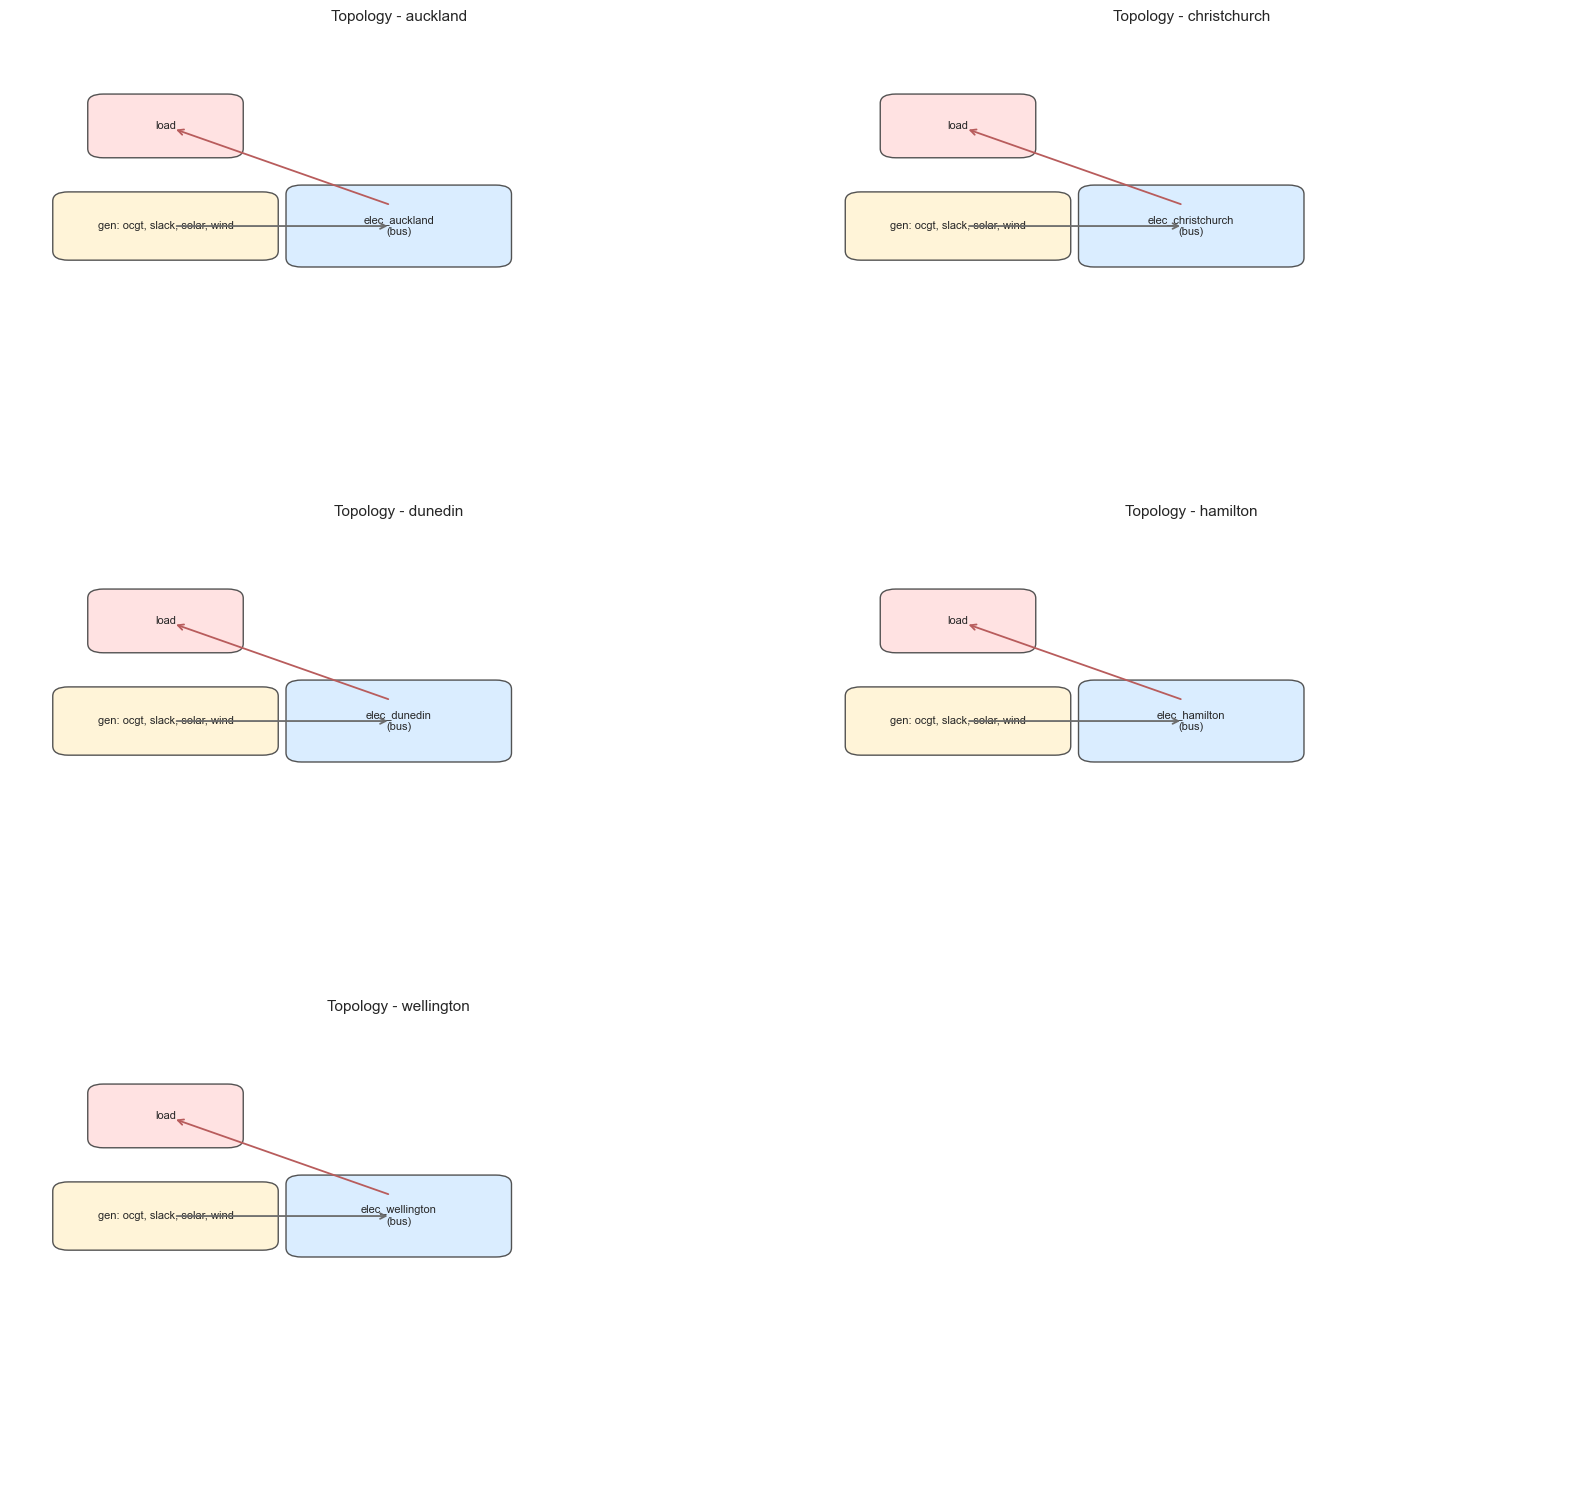

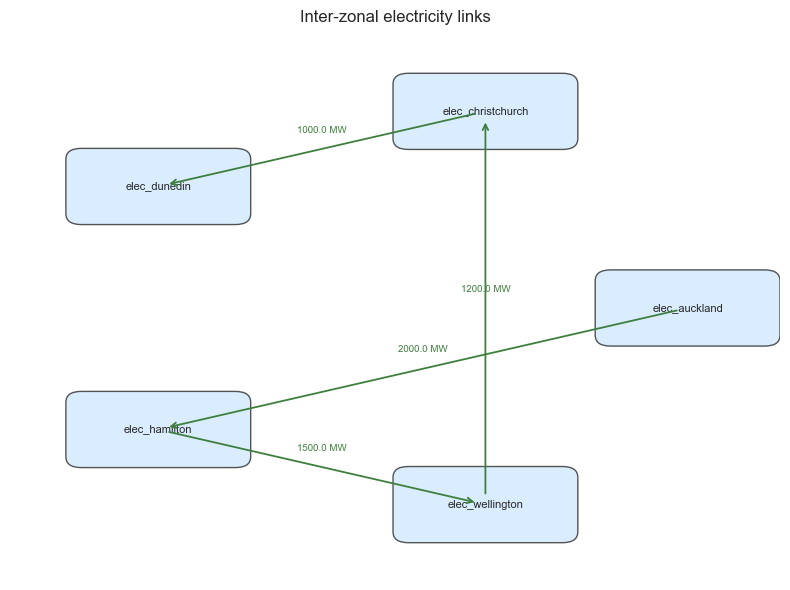

In [27]:
# System topology diagram by zone (electricity + hydrogen + UHS)
from matplotlib.patches import FancyBboxPatch
import numpy as np

def _draw_box(ax, xy, text, color="#e8eef7", width=0.2, height=0.12, fontsize=8):
    x, y = xy
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.02", linewidth=1.0, edgecolor="#4a4a4a", facecolor=color, alpha=0.95
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def _draw_arrow(ax, start, end, color="#666", text=None):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.3, color=color, shrinkA=8, shrinkB=8)
    )
    if text:
        mx = (start[0] + end[0]) / 2
        my = (start[1] + end[1]) / 2
        ax.text(mx, my + 0.03, text, fontsize=7, color=color, ha="center")

# Detect zones from electric buses
zone_names = sorted([b.replace("elec_", "") for b in n.buses.index if str(b).startswith("elec_")])
if not zone_names:
    raise ValueError("No electricity zones found in network buses.")

ncols = min(2, max(1, len(zone_names)))
nrows = int(np.ceil(len(zone_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, zone in enumerate(zone_names):
    ax = axes[i]
    ax.set_title(f"Topology - {zone}", fontsize=11, pad=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    elec_bus = f"elec_{zone}"
    h2_bus = f"h2_{zone}"
    uhs_bus = f"uhs_{zone}"

    has_h2_bus = h2_bus in n.buses.index
    has_uhs_bus = uhs_bus in n.buses.index

    # Main buses
    _draw_box(ax, (0.5, 0.58), f"{elec_bus}\n(bus)", color="#d8ecff", width=0.25, height=0.14)
    if has_h2_bus:
        _draw_box(ax, (0.5, 0.25), f"{h2_bus}\n(bus)", color="#d8ffe8", width=0.25, height=0.14)
    if has_uhs_bus:
        _draw_box(ax, (0.85, 0.25), f"{uhs_bus}\n(bus)", color="#f2f2f2", width=0.22, height=0.14)

    # Load and generators at electricity bus
    if f"load_{zone}" in n.loads.index:
        _draw_box(ax, (0.2, 0.80), "load", color="#ffe1e1", width=0.16, height=0.10)
        _draw_arrow(ax, (0.5, 0.62), (0.2, 0.80), color="#b85c5c")

    zone_gens = [g for g in n.generators.index if str(g).endswith(f"_{zone}")]
    if zone_gens:
        carriers = sorted(set(n.generators.loc[zone_gens, "carrier"].astype(str)))
        label = "gen: " + ", ".join(carriers[:4]) + ("..." if len(carriers) > 4 else "")
        _draw_box(ax, (0.2, 0.58), label, color="#fff4d6", width=0.25, height=0.11)
        _draw_arrow(ax, (0.2, 0.58), (0.5, 0.58), color="#6b6b6b")

    if f"bess_{zone}" in n.storage_units.index:
        _draw_box(ax, (0.2, 0.36), "bess", color="#efe0ff", width=0.16, height=0.10)
        _draw_arrow(ax, (0.2, 0.36), (0.5, 0.58), color="#9966cc")
        _draw_arrow(ax, (0.5, 0.58), (0.2, 0.36), color="#9966cc")

    # H2 chain components
    if has_h2_bus:
        if f"h2_electrolyzer_{zone}" in n.links.index:
            _draw_box(ax, (0.5, 0.42), "electrolyzer", color="#d7fff4", width=0.22, height=0.10)
            _draw_arrow(ax, (0.5, 0.55), (0.5, 0.44), color="#00897b")
            _draw_arrow(ax, (0.5, 0.40), (0.5, 0.30), color="#00897b")

        if f"h2_fuel_cell_{zone}" in n.links.index:
            _draw_box(ax, (0.72, 0.42), "fuel_cell", color="#ffe8cc", width=0.20, height=0.10)
            _draw_arrow(ax, (0.6, 0.25), (0.72, 0.38), color="#ff8f00")
            _draw_arrow(ax, (0.72, 0.46), (0.58, 0.58), color="#ff8f00")

        if f"h2_turbine_{zone}" in n.links.index:
            _draw_box(ax, (0.85, 0.42), "h2_turbine", color="#ede2dd", width=0.20, height=0.10)
            _draw_arrow(ax, (0.62, 0.25), (0.85, 0.38), color="#6d4c41")
            _draw_arrow(ax, (0.85, 0.46), (0.62, 0.58), color="#6d4c41")

        if f"h2_store_{zone}" in n.stores.index:
            _draw_box(ax, (0.25, 0.25), "h2_tank_store", color="#ddfff2", width=0.22, height=0.10)
            _draw_arrow(ax, (0.38, 0.25), (0.5, 0.25), color="#26a69a")
            _draw_arrow(ax, (0.5, 0.25), (0.32, 0.25), color="#26a69a")

        if f"uhs_injection_{zone}" in n.links.index:
            _draw_box(ax, (0.68, 0.16), "uhs_injection", color="#e6f0ff", width=0.20, height=0.10)
            _draw_arrow(ax, (0.58, 0.24), (0.68, 0.20), color="#3d6fb4")
            _draw_arrow(ax, (0.68, 0.12), (0.82, 0.22), color="#3d6fb4")

        if f"uhs_withdrawal_{zone}" in n.links.index:
            _draw_box(ax, (0.86, 0.10), "uhs_withdrawal", color="#e6f0ff", width=0.22, height=0.10)
            _draw_arrow(ax, (0.86, 0.20), (0.86, 0.14), color="#2f5f9e")
            _draw_arrow(ax, (0.82, 0.10), (0.58, 0.20), color="#2f5f9e")

        if f"uhs_store_{zone}" in n.stores.index:
            _draw_box(ax, (0.86, 0.34), "uhs_store", color="#f0f0f0", width=0.18, height=0.10)
            _draw_arrow(ax, (0.86, 0.28), (0.86, 0.30), color="#666")
            _draw_arrow(ax, (0.86, 0.30), (0.86, 0.26), color="#666")

    # Hydrogen demand load if present
    h2_load_id = f"h2_demand_{zone}"
    if h2_load_id in n.loads.index:
        _draw_box(ax, (0.2, 0.12), "h2_demand", color="#ffd8d8", width=0.18, height=0.10)
        _draw_arrow(ax, (0.5, 0.25), (0.2, 0.12), color="#b85c5c")

# Hide empty axes when zones < grid slots
for j in range(len(zone_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Inter-zonal electricity links (global view)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Inter-zonal electricity links", fontsize=12, pad=10)
ax.axis("off")

theta = np.linspace(0, 2 * np.pi, len(zone_names), endpoint=False)
radius = 0.38
center = np.array([0.5, 0.5])
positions = {
    z: center + radius * np.array([np.cos(t), np.sin(t)])
    for z, t in zip(zone_names, theta)
}

for z, pos in positions.items():
    _draw_box(
        ax, tuple(pos), f"elec_{z}", color="#d8ecff",
        width=0.20, height=0.10, fontsize=8
    )

seen_pairs = set()
for link_name, row in n.links.iterrows():
    if not str(link_name).startswith("link_"):
        continue
    bus0 = str(row.get("bus0", ""))
    bus1 = str(row.get("bus1", ""))
    if not (bus0.startswith("elec_") and bus1.startswith("elec_")):
        continue

    z0 = bus0.replace("elec_", "")
    z1 = bus1.replace("elec_", "")
    if z0 not in positions or z1 not in positions or z0 == z1:
        continue

    pair = tuple(sorted([z0, z1]))
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)

    p0 = positions[z0]
    p1 = positions[z1]
    cap = float(row.get("p_nom", np.nan))
    cap_txt = f"{cap:.1f} MW" if np.isfinite(cap) else None
    _draw_arrow(ax, tuple(p0), tuple(p1), color="#3e7f3e", text=cap_txt)

if not seen_pairs:
    ax.text(0.5, 0.1, "No inter-zonal electricity links found", ha="center", va="center", fontsize=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [28]:
# Georeferenced node map with capacities by technology
import folium
import numpy as np

# Color fallback in case this cell runs without cell 2
if 'TECH_COLORS' not in globals():
    TECH_COLORS = {
        'wind': '#5bbcff',
        'solar': '#ffd54f',
        'ocgt': '#b85c5c',
        'bess': '#9966cc',
        'slack': '#d32f2f',
        'natural_gas': '#bdbdbd',
        'gas': '#bdbdbd',
    }

# Reference coordinates (used if they match zone names)
zones_coords = {
    'natales': (-51.73, -72.50),
    'puntaarenas': (-53.16, -70.91),
    'porvenir': (-53.30, -70.36),
    'puertowilliams': (-54.93, -67.61),
}

# Capacities by zone and technology
gen_by_zone = (
    n.generators
    .groupby([n.generators['bus'].str.replace('elec_', '', regex=False), n.generators['carrier']])['p_nom_opt']
    .sum()
    .unstack(fill_value=0)
    .fillna(0.0)
)

# Add BESS (storage units)
if len(n.storage_units) > 0:
    bess_by_zone = n.storage_units.groupby(
        n.storage_units['bus'].str.replace('elec_', '', regex=False)
    )['p_nom_opt'].sum()
    gen_by_zone['bess'] = gen_by_zone.get('bess', 0.0)
    gen_by_zone['bess'] = gen_by_zone['bess'].add(bess_by_zone, fill_value=0.0)
    gen_by_zone = gen_by_zone.fillna(0.0)

zones = sorted(gen_by_zone.index.tolist())
if not zones:
    raise ValueError('No zones in the network to plot on the map.')

# Build coordinates: use known ones and fill missing in a circle
coords = {}
for z in zones:
    coords[z] = zones_coords[z] if z in zones_coords else None

missing = [z for z, c in coords.items() if c is None]
if missing:
    center_lat, center_lon = -53.0, -70.0
    angles = np.linspace(0, 2 * np.pi, len(missing), endpoint=False)
    for z, ang in zip(missing, angles):
        coords[z] = (center_lat + 1.0 * np.sin(ang), center_lon + 2.0 * np.cos(ang))

# Create map
center_lat = np.mean([coords[z][0] for z in zones])
center_lon = np.mean([coords[z][1] for z in zones])
m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles=None, control_scale=True)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles © Esri',
    name='Satellite (Esri)',
    overlay=False,
    control=True,
).add_to(m)
folium.TileLayer('OpenStreetMap', name='Streets (OSM)', overlay=False, control=True).add_to(m)

# Zone markers
for zone in zones:
    lat, lon = coords[zone]
    capacities = gen_by_zone.loc[zone]
    total_cap = float(capacities.sum())

    # Determine dominant technology for marker color
    tech_candidates = capacities[capacities.index.isin(['wind', 'solar', 'ocgt', 'bess'])]
    if len(tech_candidates) > 0 and tech_candidates.max() > 0:
        dominant_tech = str(tech_candidates.idxmax())
    else:
        dominant_tech = 'wind'

    marker_color = TECH_COLORS.get(dominant_tech, '#5bbcff')

    popup_text = f"<b>{zone.upper()}</b><br>"
    popup_text += f"Total capacity: {total_cap:.1f} MW<br>"
    for tech in ['wind', 'solar', 'bess', 'ocgt']:
        if tech in capacities.index and capacities[tech] > 0:
            popup_text += f"{tech}: {float(capacities[tech]):.1f} MW<br>"

    radius = max(8, min(35, 10 + total_cap / 20.0))

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=280),
        tooltip=zone,
        color='black',
        weight=2,
        fill=True,
        fillColor=marker_color,
        fillOpacity=0.75,
    ).add_to(m)

# Interconnection lines
for link_name in n.links.index:
    if not str(link_name).startswith('link_'):
        continue

    link_data = n.links.loc[link_name]
    bus0 = str(link_data['bus0']).replace('elec_', '')
    bus1 = str(link_data['bus1']).replace('elec_', '')

    if bus0 in coords and bus1 in coords:
        lat0, lon0 = coords[bus0]
        lat1, lon1 = coords[bus1]

        if link_name in n.links_t.p0.columns:
            avg_flow = float(abs(n.links_t.p0[link_name].mean()))
        else:
            avg_flow = 0.0

        weight = max(1.5, min(7.0, 1.5 + avg_flow / 100.0))

        folium.PolyLine(
            locations=[[lat0, lon0], [lat1, lon1]],
            color='green',
            weight=weight,
            opacity=0.75,
            popup=f"{link_name}: {avg_flow:.1f} MW average",
        ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 40px; right: 40px; width: 220px; z-index:9999;
            background: white; border:2px solid #444; border-radius:8px; padding:10px; font-size:12px;">
<b>Technologies</b><br>
<i style="background:#5bbcff; width: 12px; height: 12px; display: inline-block;"></i> Wind<br>
<i style="background:#ffd54f; width: 12px; height: 12px; display: inline-block;"></i> Solar<br>
<i style="background:#9966cc; width: 12px; height: 12px; display: inline-block;"></i> BESS<br>
<i style="background:#b85c5c; width: 12px; height: 12px; display: inline-block;"></i> OCGT<br><br>
<b>Circle size:</b> total capacity<br>
<b>Line width:</b> average flow
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

display(m)

print("\n=== INSTALLED CAPACITIES BY ZONE AND TECHNOLOGY [MW] ===")
display(gen_by_zone.round(2))


=== INSTALLED CAPACITIES BY ZONE AND TECHNOLOGY [MW] ===


carrier,ocgt,slack,solar,wind
bus,,,,
auckland,632.98,1000000.0,1769.63,2028.19
christchurch,528.22,1000000.0,1052.88,2281.93
dunedin,168.67,1000000.0,0.00,793.84
hamilton,240.84,1000000.0,1032.34,484.10
wellington,410.87,1000000.0,345.75,2981.10
